#**Introduction to the Comparative Model Evaluation**

This section outlines the comparative methodology utilized to evaluate the deep learning architectures designed for offline digital signature forgery detection. To determine the most effective and robust approach, a direct comparative analysis is conducted between two distinct architectures: a heavy, pre-trained ResNet18 model and a custom, lightweight Convolutional Neural Network (CNN).

The primary objective of this comparison is to empirically investigate how each architecture manages the trade-off between deep feature extraction capabilities and the inherent risk of overfitting on relatively simple binary signature images.

To ensure a fair and rigorous comparison, both models are subjected to the exact same advanced preprocessing pipeline and are trained using an identical optimized loop, which includes Automatic Mixed Precision (AMP) and an Online Hard Example Mining (OHEM) contrastive loss. The detailed performance metrics, learning curves, and diagnostic plots for each model will be presented in the following subsections.

The final conclusions and the selection of the optimal architecture for the production system will be discussed at the end of this chapter, based on the comprehensive evaluation of these results.

### Environment Setup & Library Installations

This cell resolves potential environment conflicts with OpenCV by completely uninstalling existing versions and installing the clean, headless version. It also ensures that the PyTorch and TorchVision libraries are upgraded to their latest versions to properly support the deep learning architecture.

In [ ]:
# @title
# Cell - Delete combined_dataset
import shutil
import os

dir_to_delete = 'ChiSig_extracted'

# Check if the directory exists before trying to delete it
if os.path.exists(dir_to_delete):
    shutil.rmtree(dir_to_delete)
    print(f"Successfully deleted the '{dir_to_delete}' folder and all its contents!")
else:
    print(f"The folder '{dir_to_delete}' does not exist. You are good to go!")

In [ ]:
# @title
# Cell - Delete combined_dataset
import shutil
import os

dir_to_delete = 'combined_dataset'

# Check if the directory exists before trying to delete it
if os.path.exists(dir_to_delete):
    shutil.rmtree(dir_to_delete)
    print(f"Successfully deleted the '{dir_to_delete}' folder and all its contents!")
else:
    print(f"The folder '{dir_to_delete}' does not exist. You are good to go!")

In [ ]:
# Environment Setup
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
!pip install opencv-python-headless
!pip install --upgrade torch torchvision

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/1

### Base Dataset Extraction & Auto-Location

This cell extracts the base English signature dataset from the uploaded `archive.zip` file. Once extracted, it automatically traverses the directory tree to locate the `full_org` and `full_forg` folders, saving the path for the upcoming merging steps.

In [ ]:
# Cell 0 - Unzip and Auto-Locate Data
import zipfile
import os

zip_file_path = 'archive.zip'
if os.path.exists(zip_file_path):
    print(f"Extracting {zip_file_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Extraction complete!")
else:
    print(f"Zip file '{zip_file_path}' not found. Assuming data is already extracted.")

# Automatically find the path that contains the signature folders
detected_data_path = None
for root, dirs, files in os.walk('.'):
    if 'full_org' in dirs and 'full_forg' in dirs:
        detected_data_path = root
        break

if detected_data_path is not None:
    print(f"\nSUCCESS: Found signature folders at: {detected_data_path}")
else:
    print("\n[!] ERROR: Could not find 'full_org' and 'full_forg' folders.")
    print("Please make sure your zip file contains these folders.")

Extracting archive.zip...
Extraction complete!

SUCCESS: Found signature folders at: ./archive/signatures


### Libraries Import & Seed Initialization

This step imports all the necessary Python modules required for data manipulation, computer vision, and building the neural network (PyTorch, OpenCV, PIL, etc.). It also fixes the random seeds globally to ensure that data splitting and training results remain completely reproducible across different runs.

In [ ]:
# Cell 1 - Setup and Imports
import os
import random
import cv2
import torch
import collections
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from google.colab import files #Ignore if running locally

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

print("Cell 1 Complete: All libraries imported successfully.")

Cell 1 Complete: All libraries imported successfully.


### Master Dataset Builder (All Languages)

This massive data processing pipeline creates a unified master dataset by merging three distinct signature databases: the original English dataset, BHSig260 (Hindi and Bengali), and ChiSig (Chinese). It parses complex filenames, maps author strings to unique integer IDs to prevent overlap, and standardizes all images into a clean `full_org` and `full_forg` folder structure.

In [ ]:
# Cell 2 - CLEAN UNIFIED DATASET MERGE (No Augmentations)
import os
import shutil
import zipfile
import re
from PIL import Image
from tqdm import tqdm

combined_data_dir = 'combined_dataset'

# 1. Clean up and recreate directories (ONCE)
print("Cleaning and preparing 'combined_dataset' folder...")
if os.path.exists(combined_data_dir):
    shutil.rmtree(combined_data_dir)
os.makedirs(os.path.join(combined_data_dir, 'full_org'), exist_ok=True)
os.makedirs(os.path.join(combined_data_dir, 'full_forg'), exist_ok=True)

# 2. Add Original Dataset (English) - CLEAN ONLY
# USING THE AUTO-DETECTED PATH FROM CELL 0
try:
    clean_english_dir = detected_data_path
except NameError:
    clean_english_dir = None

if clean_english_dir is not None and os.path.exists(clean_english_dir):
    print("\n[1/3] Copying CLEAN English dataset...")
    for sub_dir in ['full_org', 'full_forg']:
        src_dir = os.path.join(clean_english_dir, sub_dir)
        dst_dir = os.path.join(combined_data_dir, sub_dir)
        if os.path.exists(src_dir):
            for filename in os.listdir(src_dir):
                shutil.copy(os.path.join(src_dir, filename), os.path.join(dst_dir, filename))
    print("Clean English dataset copied successfully.")
else:
    print(f"\n[!] Clean English dataset not found. Please ensure Cell 0 was run.")

# 3. Add BHSig260 Dataset (Hindi/Bengali)
bhsig_zip_path = 'BHSig260.zip'
bhsig_raw_dir = 'BHSig_extracted'
if os.path.exists(bhsig_zip_path):
    print("\n[2/3] Extracting and processing BHSig260...")
    with zipfile.ZipFile(bhsig_zip_path, 'r') as zip_ref:
        zip_ref.extractall(bhsig_raw_dir)

    bhsig_count = 0
    for root, dirs, files in os.walk(bhsig_raw_dir):
        for filename in files:
            if filename.lower().endswith('.tif'):
                match = re.match(r'([BHbh])-[Ss]-(\d+)-([GgFf])-(\d+)', filename)
                if match:
                    lang = match.group(1).upper()
                    author_id = int(match.group(2))
                    sig_type = match.group(3).upper()
                    sig_num = int(match.group(4))
                    unique_id = author_id + (6000 if lang == 'B' else 7000)

                    dest_folder = os.path.join(combined_data_dir, 'full_org' if sig_type == 'G' else 'full_forg')
                    prefix = 'org' if sig_type == 'G' else 'forg'

                    try:
                        img = Image.open(os.path.join(root, filename)).convert('L')
                        img.save(os.path.join(dest_folder, f"bhsig_{prefix}_{unique_id}_{sig_num}.jpg"), 'JPEG')
                        bhsig_count += 1
                    except Exception:
                        pass
    print(f"Added {bhsig_count} BHSig260 signatures.")

# 4. Add ChiSig Dataset (Chinese)
chisig_zip_path = 'ChiSig.zip'
chisig_raw_dir = 'ChiSig_extracted'
if os.path.exists(chisig_zip_path):
    print("\n[3/3] Extracting and processing ChiSig...")
    with zipfile.ZipFile(chisig_zip_path, 'r') as zip_ref:
        zip_ref.extractall(chisig_raw_dir)

    chinese_name_to_id = {}
    current_author_idx = 1
    CHISIG_ID_OFFSET = 2000
    chisig_count = 0

    chisig_images_folder = None
    for root, dirs, files in os.walk(chisig_raw_dir):
        if any(f.endswith(('.jpg', '.png')) for f in files):
            chisig_images_folder = root
            break

    if chisig_images_folder:
        files_to_process = [f for f in os.listdir(chisig_images_folder) if f.endswith(('.jpg', '.png'))]
        for filename in tqdm(files_to_process, desc="Merging ChiSig"):
            parts = filename.rsplit('.', 1)[0].split('-')
            if len(parts) >= 3:
                try:
                    author_name = parts[0]
                    middle_num = int(parts[1])
                    sample_num = int(parts[2])

                    if author_name not in chinese_name_to_id:
                        chinese_name_to_id[author_name] = current_author_idx
                        current_author_idx += 1

                    mapped_author_id = chinese_name_to_id[author_name]
                    real_id = mapped_author_id + CHISIG_ID_OFFSET

                    if middle_num < 100:
                        new_name = f"chisig_org_{real_id}_{sample_num}.jpg"
                        dest_folder = os.path.join(combined_data_dir, 'full_org')
                    else:
                        new_name = f"chisig_forg_{real_id}_{sample_num}.jpg"
                        dest_folder = os.path.join(combined_data_dir, 'full_forg')

                    shutil.copy(os.path.join(chisig_images_folder, filename), os.path.join(dest_folder, new_name))
                    chisig_count += 1
                except ValueError:
                    pass
    print(f"Added {chisig_count} ChiSig signatures.")

print("\n" + "="*50)
print("CLEAN MASTER MERGE COMPLETE! YOUR DATASET IS READY!")
print("="*50)

Cleaning and preparing 'combined_dataset' folder...

[1/3] Copying CLEAN English dataset...
Clean English dataset copied successfully.

[2/3] Extracting and processing BHSig260...
Added 14040 BHSig260 signatures.

[3/3] Extracting and processing ChiSig...


Merging ChiSig: 100%|██████████| 10242/10242 [00:04<00:00, 2102.87it/s]

Added 10242 ChiSig signatures.

CLEAN MASTER MERGE COMPLETE! YOUR DATASET IS READY!


### Advanced DataLoaders with Unified Preprocessing

This cell builds the core dataset pipeline. It integrates the unified preprocessing logic (`UnifiedSignatureTransform`) directly into the DataLoader, ensuring that every image is dynamically deskewed, cropped, and inverse-binarized on the fly during training. It also splits the authors into strictly isolated Train, Validation, and Test sets to prevent data leakage.

In [ ]:
# One-Time Preprocessing Script
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

source_dir = 'combined_dataset'
dest_dir = 'processed_dataset'

# 1. Create destination directories
for folder in ['full_org', 'full_forg']:
    os.makedirs(os.path.join(dest_dir, folder), exist_ok=True)

# 2. Define the heavy processing function (extracted from UnifiedSignatureTransform)
def process_and_save(img_path, save_path):
    img = Image.open(img_path).convert('L')
    img_np = np.array(img)

    blurred = cv2.GaussianBlur(img_np, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    M_moments = cv2.moments(thresh)
    angle = 0
    if M_moments['m00'] > 0:
        mu20 = M_moments['mu20']
        mu02 = M_moments['mu02']
        mu11 = M_moments['mu11']
        if (mu20 - mu02) != 0:
            angle_rad = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
            angle_deg = np.degrees(angle_rad)
            if -45 < angle_deg < 45: angle = angle_deg

    (h, w) = img_np.shape[:2]
    center = (w // 2, h // 2)
    M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(thresh, M_rot, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    coords = cv2.findNonZero(rotated)
    if coords is not None and len(coords) > 50:
        x, y, w_crop, h_crop = cv2.boundingRect(coords)
        pad = 15
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(w, x + w_crop + pad), min(h, y + h_crop + pad)
        cropped = rotated[y1:y2, x1:x2]
    else:
        cropped = rotated

    h_c, w_c = cropped.shape[:2]
    target_size = max(h_c, w_c)
    top = (target_size - h_c) // 2
    bottom = target_size - h_c - top
    left = (target_size - w_c) // 2
    right = target_size - w_c - left

    squared = cv2.copyMakeBorder(cropped, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)
    final_img = cv2.resize(squared, (224, 224))

    # Save the fully processed image
    Image.fromarray(final_img).save(save_path)

# 3. Execute processing loop
print("Starting one-time preprocessing. Please wait...")
for folder in ['full_org', 'full_forg']:
    src_folder = os.path.join(source_dir, folder)
    dst_folder = os.path.join(dest_dir, folder)
    if not os.path.exists(src_folder): continue

    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
    for img_name in tqdm(images, desc=f"Processing {folder}"):
        src_path = os.path.join(src_folder, img_name)
        dst_path = os.path.join(dst_folder, img_name)
        process_and_save(src_path, dst_path)

print("Preprocessing complete! Images are ready in 'processed_dataset'.")

Starting one-time preprocessing. Please wait...


Processing full_forg: 100%|██████████| 10968/10968 [01:15<00:00, 145.88it/s]

Preprocessing complete! Images are ready in 'processed_dataset'.


In [ ]:
# Cell 3 - Fast DataLoaders with Pre-processed Data & Smart Sampling ####### NEW #######
import os
import re
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# 1. Define fast transformations (Removed heavy cv2 operations)
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    transforms.ToTensor()
])

test_val_transforms = transforms.Compose([
    transforms.ToTensor()
])

# 2. Siamese Network Dataset Class
class SiameseSignatureDataset(Dataset):
    def __init__(self, data_dict, transform=None, max_gen=100, max_forg=100):
        self.data_dict = data_dict
        self.transform = transform
        self.author_ids = list(data_dict.keys())
        self.pairs = []

        for author_id in self.author_ids:
            orgs = data_dict[author_id].get('org', [])
            forgs = data_dict[author_id].get('forg', [])

            all_gen_pairs = [(orgs[i], orgs[j], 1) for i in range(len(orgs)) for j in range(i + 1, len(orgs))]
            all_forg_pairs = [(org_img, forg_img, 0) for org_img in orgs for forg_img in forgs]

            sampled_gen = random.sample(all_gen_pairs, max_gen) if len(all_gen_pairs) > max_gen else all_gen_pairs
            sampled_forg = random.sample(all_forg_pairs, max_forg) if len(all_forg_pairs) > max_forg else all_forg_pairs

            self.pairs.extend(sampled_gen)
            self.pairs.extend(sampled_forg)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]
        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

# 3. Scan PROCESSED data and map by authors
processed_data_dir = 'processed_dataset'
all_data = {}
print("Scanning processed dataset...")
for label_type in ['full_org', 'full_forg']:
    folder_path = os.path.join(processed_data_dir, label_type)
    if not os.path.exists(folder_path): continue
    key_name = 'org' if label_type == 'full_org' else 'forg'
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg', '.tif', '.tiff')):
            numbers = re.findall(r'\d+', filename)
            if numbers:
                author_id = int(numbers[0])
                if author_id not in all_data: all_data[author_id] = {'org': [], 'forg': []}
                all_data[author_id][key_name].append(os.path.join(folder_path, filename))

# 4. Split into Train, Validation, and Test
all_author_ids = sorted(list(all_data.keys()))
random.seed(42)
random.shuffle(all_author_ids)

total_authors = len(all_author_ids)
train_split, val_split = int(0.70 * total_authors), int(0.85 * total_authors)

train_dict = {k: all_data[k] for k in all_author_ids[:train_split]}
val_dict = {k: all_data[k] for k in all_author_ids[train_split:val_split]}
test_dict = {k: all_data[k] for k in all_author_ids[val_split:]}

# 5. Build datasets with caps
MAX_GEN, MAX_FORG = 100, 100
train_dataset = SiameseSignatureDataset(train_dict, transform=train_transforms, max_gen=MAX_GEN, max_forg=MAX_FORG)
val_dataset = SiameseSignatureDataset(val_dict, transform=test_val_transforms, max_gen=MAX_GEN, max_forg=MAX_FORG)
test_dataset = SiameseSignatureDataset(test_dict, transform=test_val_transforms, max_gen=MAX_GEN, max_forg=MAX_FORG)

# 6. Create DataLoaders (Optimized for Speed and AMP)
batch_size = 64
workers = 2

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)

print("\n=== Data Summary ===")
print(f"Train: {len(train_dataset):,} pairs | Validation: {len(val_dataset):,} pairs | Test: {len(test_dataset):,} pairs")
print("\nCell 3 Complete: Fast Dataloaders ready!")

Scanning processed dataset...

=== Data Summary ===
Train: 53,614 pairs | Validation: 12,741 pairs | Test: 12,612 pairs

Cell 3 Complete: Fast Dataloaders ready!


In [ ]:
# @title
# Cell 3 - Advanced DataLoaders with Unified Preprocessing & Smart Sampling ### OLD ####
import os
import re
import random
import cv2
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# 1. Unified Transform (Deskew, Crop, Inverse Binarize)
class UnifiedSignatureTransform(object):
    """
    Applies the full preprocessing pipeline on the fly:
    Otsu Binarization (Inverse) -> Deskew -> Crop -> Pad -> Resize.
    """
    def __call__(self, img):
        img_np = np.array(img)

        blurred = cv2.GaussianBlur(img_np, (5, 5), 0)
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        M_moments = cv2.moments(thresh)
        angle = 0
        if M_moments['m00'] > 0:
            mu20 = M_moments['mu20']
            mu02 = M_moments['mu02']
            mu11 = M_moments['mu11']
            if (mu20 - mu02) != 0:
                angle_rad = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
                angle_deg = np.degrees(angle_rad)
                if -45 < angle_deg < 45: angle = angle_deg

        (h, w) = img_np.shape[:2]
        center = (w // 2, h // 2)
        M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(thresh, M_rot, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        coords = cv2.findNonZero(rotated)
        if coords is not None and len(coords) > 50:
            x, y, w_crop, h_crop = cv2.boundingRect(coords)
            pad = 15
            x1, y1 = max(0, x - pad), max(0, y - pad)
            x2, y2 = min(w, x + w_crop + pad), min(h, y + h_crop + pad)
            cropped = rotated[y1:y2, x1:x2]
        else:
            cropped = rotated

        h_c, w_c = cropped.shape[:2]
        target_size = max(h_c, w_c)
        top = (target_size - h_c) // 2
        bottom = target_size - h_c - top
        left = (target_size - w_c) // 2
        right = target_size - w_c - left

        squared = cv2.copyMakeBorder(cropped, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)
        final_img = cv2.resize(squared, (224, 224))

        return Image.fromarray(final_img)

# 2. Define transformations
train_transforms = transforms.Compose([
    UnifiedSignatureTransform(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    transforms.ToTensor()
])

test_val_transforms = transforms.Compose([
    UnifiedSignatureTransform(),
    transforms.ToTensor()
])

# 3. Siamese Network Dataset Class
class SiameseSignatureDataset(Dataset):
    def __init__(self, data_dict, transform=None, max_gen=100, max_forg=100):
        self.data_dict = data_dict
        self.transform = transform
        self.author_ids = list(data_dict.keys())
        self.pairs = []

        for author_id in self.author_ids:
            orgs = data_dict[author_id].get('org', [])
            forgs = data_dict[author_id].get('forg', [])

            all_gen_pairs = [(orgs[i], orgs[j], 1) for i in range(len(orgs)) for j in range(i + 1, len(orgs))]
            all_forg_pairs = [(org_img, forg_img, 0) for org_img in orgs for forg_img in forgs]

            sampled_gen = random.sample(all_gen_pairs, max_gen) if len(all_gen_pairs) > max_gen else all_gen_pairs
            sampled_forg = random.sample(all_forg_pairs, max_forg) if len(all_forg_pairs) > max_forg else all_forg_pairs

            self.pairs.extend(sampled_gen)
            self.pairs.extend(sampled_forg)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]
        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

# 4. Scan data and map by authors
combined_data_dir = 'combined_dataset'
all_data = {}
print("Scanning unified dataset...")
for label_type in ['full_org', 'full_forg']:
    folder_path = os.path.join(combined_data_dir, label_type)
    if not os.path.exists(folder_path): continue
    key_name = 'org' if label_type == 'full_org' else 'forg'
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg', '.tif')):
            numbers = re.findall(r'\d+', filename)
            if numbers:
                author_id = int(numbers[0])
                if author_id not in all_data: all_data[author_id] = {'org': [], 'forg': []}
                all_data[author_id][key_name].append(os.path.join(folder_path, filename))

# 5. Split into Train, Validation, and Test
all_author_ids = sorted(list(all_data.keys()))
random.seed(42)
random.shuffle(all_author_ids)

total_authors = len(all_author_ids)
train_split, val_split = int(0.70 * total_authors), int(0.85 * total_authors)

train_dict = {k: all_data[k] for k in all_author_ids[:train_split]}
val_dict = {k: all_data[k] for k in all_author_ids[train_split:val_split]}
test_dict = {k: all_data[k] for k in all_author_ids[val_split:]}

# 6. Build datasets with caps
MAX_GEN, MAX_FORG = 100, 100
train_dataset = SiameseSignatureDataset(train_dict, transform=train_transforms, max_gen=MAX_GEN, max_forg=MAX_FORG)
val_dataset = SiameseSignatureDataset(val_dict, transform=test_val_transforms, max_gen=MAX_GEN, max_forg=MAX_FORG)
test_dataset = SiameseSignatureDataset(test_dict, transform=test_val_transforms, max_gen=MAX_GEN, max_forg=MAX_FORG)

# 7. Create DataLoaders (Optimized for Speed and AMP)
batch_size = 64 # Increased batch size for AMP
workers = 2 # Set to 2 for Colab

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)

print("\n=== Data Summary ===")
print(f"Train: {len(train_dataset):,} pairs | Validation: {len(val_dataset):,} pairs | Test: {len(test_dataset):,} pairs")
print("\nCell 3 Complete: Dataloaders ready with Unified Preprocessing and Optimized Memory!")

### Dataset Distribution Summary

This cell iterates through the loaded dataset dictionary to calculate and display a detailed summary of the data distribution. It identifies the origin of each signature (Original English, BHSig260, or ChiSig) based on filename prefixes, and outputs the total number of unique authors and images contributed by each distinct dataset.

In [ ]:
# Cell 3.1 - Dataset Distribution Summary (Authors and Images)

english_authors = 0
english_images = 0

bhsig_authors = 0
bhsig_images = 0

chisig_authors = 0
chisig_images = 0

# Scan the dictionary where all data is organized by authors
for author, data in all_data.items():
    all_images_for_author = data['org'] + data['forg']

    # Ensure the author has at least one image to identify their dataset origin
    if len(all_images_for_author) > 0:
        sample_filename = all_images_for_author[0].lower()
        num_images = len(all_images_for_author)

        # Classify and count by dataset
        if 'bhsig' in sample_filename:
            bhsig_authors += 1
            bhsig_images += num_images
        elif 'chisig' in sample_filename:
            chisig_authors += 1
            chisig_images += num_images
        else:
            # If there's no specific prefix, it belongs to the original English dataset
            english_authors += 1
            english_images += num_images

# --- Formatted Output ---
print("=" * 50)
print("📊 DATASET DISTRIBUTION SUMMARY 📊")
print("=" * 50)

print(f"🌍 English (Original) Dataset:")
print(f"   -> Authors: {english_authors:,}")
print(f"   -> Images:  {english_images:,}")
print("-" * 50)

print(f"🇮🇳 BHSig260 (Hindi/Bengali) Dataset:")
print(f"   -> Authors: {bhsig_authors:,}")
print(f"   -> Images:  {bhsig_images:,}")
print("-" * 50)

print(f"🇨🇳 ChiSig (Chinese) Dataset:")
print(f"   -> Authors: {chisig_authors:,}")
print(f"   -> Images:  {chisig_images:,}")
print("=" * 50)

total_authors = english_authors + bhsig_authors + chisig_authors
total_images = english_images + bhsig_images + chisig_images

print(f"✅ TOTAL AUTHORS: {total_authors:,}")
print(f"✅ TOTAL IMAGES:  {total_images:,}")
print("=" * 50)

📊 DATASET DISTRIBUTION SUMMARY 📊
🌍 English (Original) Dataset:
   -> Authors: 109
   -> Images:  3,356
--------------------------------------------------
🇮🇳 BHSig260 (Hindi/Bengali) Dataset:
   -> Authors: 260
   -> Images:  14,016
--------------------------------------------------
🇨🇳 ChiSig (Chinese) Dataset:
   -> Authors: 500
   -> Images:  3,989
✅ TOTAL AUTHORS: 869
✅ TOTAL IMAGES:  21,361


In [ ]:
# @title
# Cell 3.1 - Save Dataset Pairs (Train, Val, Test Splits)
import pickle

# Save the exact generated pairs to maintain the exact data split
dataset_splits = {
    'train_pairs': train_dataset.pairs,
    'val_pairs': val_dataset.pairs,
    'test_pairs': test_dataset.pairs
}

with open('dataset_splits.pkl', 'wb') as f:
    pickle.dump(dataset_splits, f)

print("Cell 3.8 Complete: Dataset pairs successfully saved to 'dataset_splits.pkl'")

Cell 3.8 Complete: Dataset pairs successfully saved to 'dataset_splits.pkl'


In [ ]:
# @title
# Cell 3.2 - Load Dataset Pairs & Rebuild DataLoaders (Use only after notebook restart)
import pickle
from torch.utils.data import DataLoader

try:
    with open('dataset_splits.pkl', 'rb') as f:
        dataset_splits = pickle.load(f)

    # Assign the saved pairs back to the datasets
    train_dataset.pairs = dataset_splits['train_pairs']
    val_dataset.pairs = dataset_splits['val_pairs']
    test_dataset.pairs = dataset_splits['test_pairs']

    # Rebuild the dataloaders instantly
    batch_size = 32
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Cell 3.9 Complete: DataLoaders rebuilt successfully from saved state!")
    print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")

except FileNotFoundError:
    print("[!] 'dataset_splits.pkl' not found. Please run Cell 3 and 3.8 first.")

### Data Distribution Summary

This cell calculates and prints the exact number of image pairs generated for the training, validation, and testing sets. It provides a clear, high-level overview of the data distribution and the total number of individual images participating in the model's training process.

In [ ]:
print("=== פירוט כמות הנתונים במודל (בזוגות) ===")
print(f"Train (אימון): {len(train_dataset):,} זוגות")
print(f"Validation (ולידציה): {len(val_dataset):,} זוגות")
print(f"Test (מבחן): {len(test_dataset):,} זוגות")

print("-" * 40)
total_pairs = len(train_dataset) + len(val_dataset) + len(test_dataset)
print(f"סה\"כ זוגות שנוצרו: {total_pairs:,}")
print(f"סה\"כ תמונות בודדות שלוקחות חלק בתהליך: {total_pairs * 2:,}")

=== פירוט כמות הנתונים במודל (בזוגות) ===
Train (אימון): 53,614 זוגות
Validation (ולידציה): 12,741 זוגות
Test (מבחן): 12,612 זוגות
----------------------------------------
סה"כ זוגות שנוצרו: 78,967
סה"כ תמונות בודדות שלוקחות חלק בתהליך: 157,934


### Raw Dataset Visualization

Before any heavy preprocessing or training occurs, this cell randomly selects and displays genuine and forged signature samples directly from the raw dataset. It serves as a visual sanity check to ensure the images are loaded correctly and categorized in the right folders.

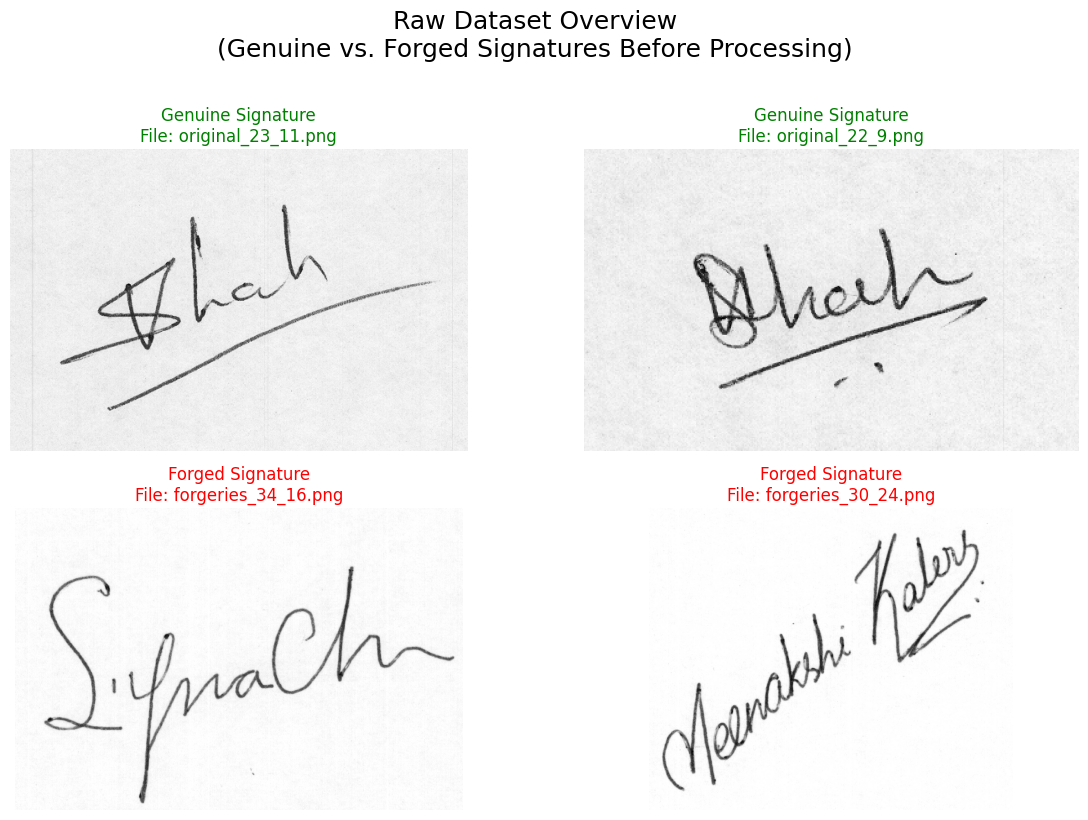

In [ ]:
# Cell 3.4 - Visualize Raw Dataset (Before Any Processing/Training)
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_raw_dataset_samples(base_dir):
    if base_dir is None or not os.path.exists(base_dir):
        print("[!] Source directory not found. Please ensure data is extracted.")
        return

    org_dir = os.path.join(base_dir, 'full_org')
    forg_dir = os.path.join(base_dir, 'full_forg')

    # Fetch all valid image files
    org_files = [f for f in os.listdir(org_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    forg_files = [f for f in os.listdir(forg_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not org_files or not forg_files:
        print("[!] Images not found in one of the directories.")
        return

    # Select random samples (2 genuine, 2 forged)
    random_orgs = random.sample(org_files, 2)
    random_forgs = random.sample(forg_files, 2)

    # Set up the plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Raw Dataset Overview\n(Genuine vs. Forged Signatures Before Processing)', fontsize=18, y=1.02)

    # Plot Genuine Signatures (Top Row)
    for i in range(2):
        img_path = os.path.join(org_dir, random_orgs[i])
        img = Image.open(img_path).convert('L')
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'Genuine Signature\nFile: {random_orgs[i]}', fontsize=12, color='green')
        axes[0, i].axis('off')

    # Plot Forged Signatures (Bottom Row)
    for i in range(2):
        img_path = os.path.join(forg_dir, random_forgs[i])
        img = Image.open(img_path).convert('L')
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f'Forged Signature\nFile: {random_forgs[i]}', fontsize=12, color='red')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
try:
    show_raw_dataset_samples(detected_data_path)
except NameError:
    print("[!] 'detected_data_path' not found. Please run the extraction cell first.")

### Processed Dataset Visualization

This cell fetches a batch of images directly from the training dataloader to verify the effects of the preprocessing pipeline. It displays the images after they have undergone dynamic Otsu thresholding, deskewing, cropping, and padding, confirming that the model receives clean, normalized inputs.

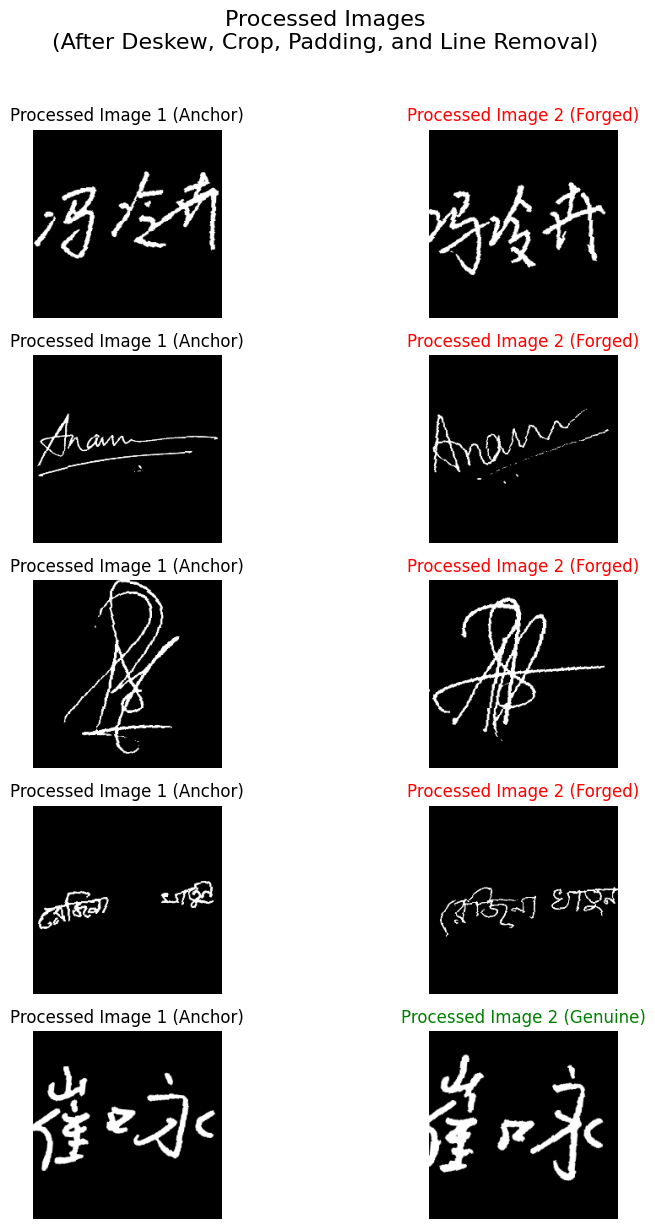

In [ ]:
# Cell 3.5 - Visualize PROCESSED Dataset (After Deskew, Crop, and Line Removal)
import matplotlib.pyplot as plt

def show_processed_batch(dataloader):
    # Fetch a single batch of processed images
    images1, images2, labels = next(iter(dataloader))

    num_examples = 5
    fig, axes = plt.subplots(num_examples, 2, figsize=(10, 12))
    fig.suptitle('Processed Images\n(After Deskew, Crop, Padding, and Line Removal)', fontsize=16, y=1.02)

    for i in range(num_examples):
        # Tensors are in shape [1, 224, 224], squeeze to [224, 224] for plotting
        img1_np = images1[i].squeeze().numpy()
        img2_np = images2[i].squeeze().numpy()
        label = int(labels[i].item())

        # Anchor Image
        axes[i, 0].imshow(img1_np, cmap='gray')
        axes[i, 0].set_title("Processed Image 1 (Anchor)")
        axes[i, 0].axis('off')

        # Test Image
        axes[i, 1].imshow(img2_np, cmap='gray')
        match_text = "Genuine" if label == 1 else "Forged"
        color = 'green' if label == 1 else 'red'
        axes[i, 1].set_title(f"Processed Image 2 ({match_text})", color=color)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization on the training dataloader
show_processed_batch(train_dataloader)

### Raw vs. Unified Processed Data Comparison

This cell provides a side-by-side visual comparison of genuine and forged signature pairs before and after applying the unified preprocessing pipeline. It clearly demonstrates the effect of deskewing, tight cropping, and inverse binarization (converting paper to a pure black background and ink to a white signal), which is critical for maximizing the neural network's feature extraction efficiency.

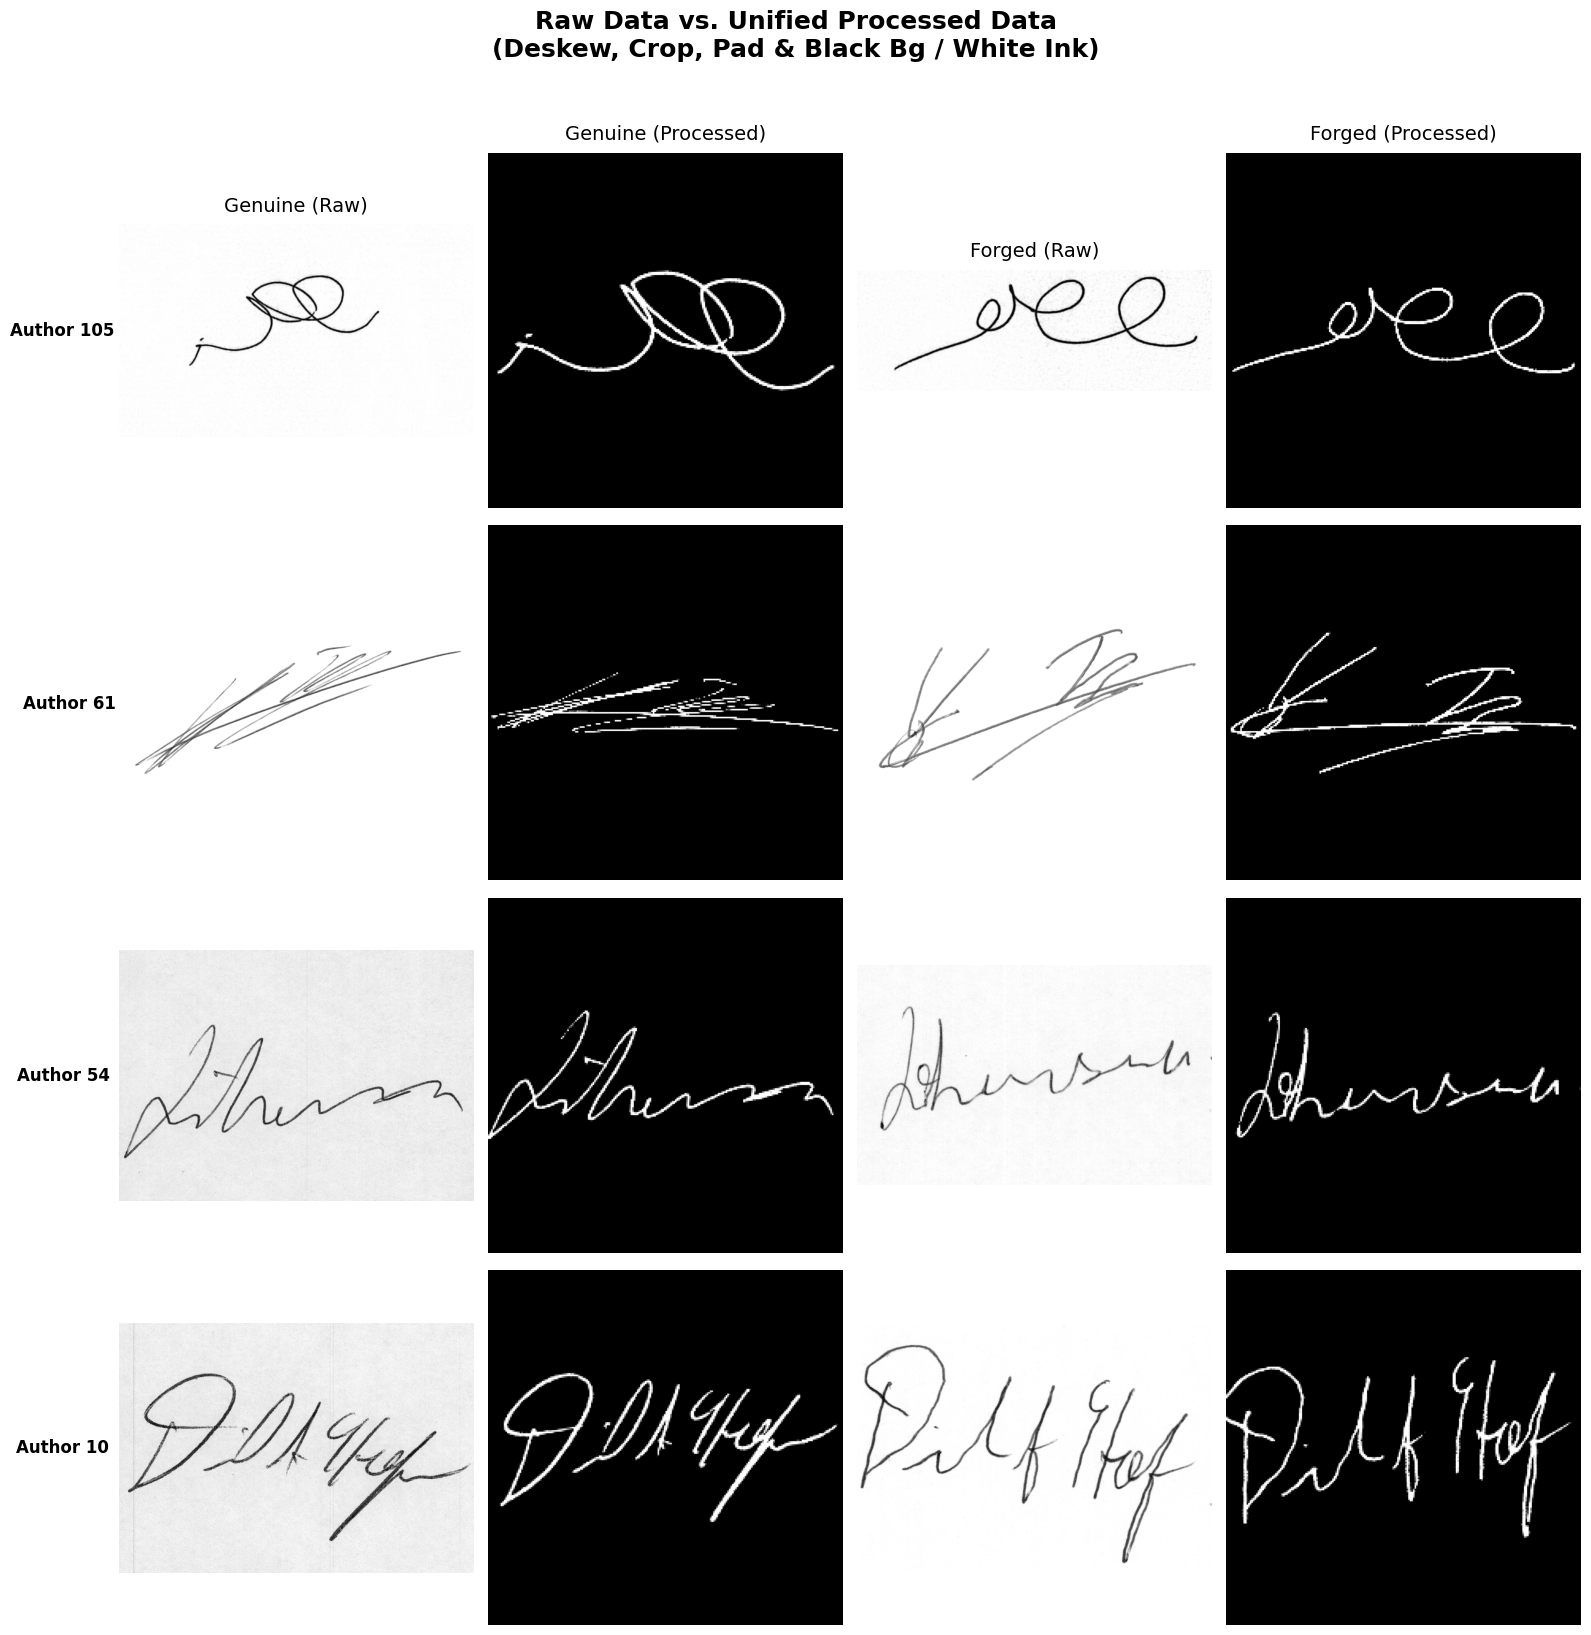

In [ ]:
# Cell 3.6 - Raw vs. Fully Processed Data (Unified Preprocessing)
import os
import random
import collections
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def apply_unified_preprocessing(image_path):
    # Load as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros((224, 224), dtype=np.float32)

    # 1. Blur & Binarize (Inverse: Ink becomes 255, Paper becomes 0)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 2. Deskew (Calculate angle using moments)
    M_moments = cv2.moments(thresh)
    angle = 0
    if M_moments['m00'] > 0:
        mu20 = M_moments['mu20']
        mu02 = M_moments['mu02']
        mu11 = M_moments['mu11']
        if (mu20 - mu02) != 0:
            angle_rad = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
            angle_deg = np.degrees(angle_rad)
            if -45 < angle_deg < 45:
                angle = angle_deg

    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Rotate mask (borderValue=0 keeps background black)
    rotated_thresh = cv2.warpAffine(thresh, M_rot, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

    # 3. Crop tightly around the ink
    coords = cv2.findNonZero(rotated_thresh)
    if coords is not None and len(coords) > 50:
        x, y, w_crop, h_crop = cv2.boundingRect(coords)
        if w_crop > 20 and h_crop > 20:
            pad = 15
            x1, y1 = max(0, x - pad), max(0, y - pad)
            x2, y2 = min(w, x + w_crop + pad), min(h, y + h_crop + pad)
            cropped = rotated_thresh[y1:y2, x1:x2]
        else:
            cropped = rotated_thresh
    else:
        cropped = rotated_thresh

    # 4. Pad to square & Resize
    h_c, w_c = cropped.shape[:2]
    target_size = max(h_c, w_c)
    top = (target_size - h_c) // 2
    bottom = target_size - h_c - top
    left = (target_size - w_c) // 2
    right = target_size - w_c - left

    # borderValue=0 ensures the padding is pure black
    squared = cv2.copyMakeBorder(cropped, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)
    final_img = cv2.resize(squared, (224, 224))

    return Image.fromarray(final_img)

def show_raw_vs_processed(base_dir, num_pairs=5):
    if base_dir is None or not os.path.exists(base_dir):
        print("[!] Source directory not found. Please ensure data is extracted.")
        return

    org_dir = os.path.join(base_dir, 'full_org')
    forg_dir = os.path.join(base_dir, 'full_forg')

    import re
    def parse_author(filename):
        match = re.search(r'(?:original|forgeries|org|forg)[_-]?(\d+)', filename.lower())
        if match: return int(match.group(1))
        match = re.search(r'(\d+)', filename)
        if match: return int(match.group(1))
        return None

    org_dict = collections.defaultdict(list)
    forg_dict = collections.defaultdict(list)
    supported_exts = ['.png', '.jpg', '.jpeg']

    for f in os.listdir(org_dir):
        if os.path.splitext(f)[1].lower() in supported_exts:
            author = parse_author(f)
            if author is not None: org_dict[author].append(os.path.join(org_dir, f))

    for f in os.listdir(forg_dir):
        if os.path.splitext(f)[1].lower() in supported_exts:
            author = parse_author(f)
            if author is not None: forg_dict[author].append(os.path.join(forg_dir, f))

    valid_authors = [a for a in org_dict if len(org_dict[a]) > 0 and len(forg_dict.get(a, [])) > 0]
    num_pairs = min(len(valid_authors), num_pairs)
    selected_authors = random.sample(valid_authors, num_pairs)

    fig, axes = plt.subplots(num_pairs, 4, figsize=(16, 4 * num_pairs))
    fig.suptitle('Raw Data vs. Unified Processed Data\n(Deskew, Crop, Pad & Black Bg / White Ink)', fontsize=18, y=1.02, fontweight='bold')

    col_titles = ['Genuine (Raw)', 'Genuine (Processed)', 'Forged (Raw)', 'Forged (Processed)']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=14, pad=10)

    for row, author in enumerate(selected_authors):
        org_path = random.choice(org_dict[author])
        forg_path = random.choice(forg_dict[author])

        img_org_raw = Image.open(org_path).convert('L')
        img_forg_raw = Image.open(forg_path).convert('L')
        img_org_proc = apply_unified_preprocessing(org_path)
        img_forg_proc = apply_unified_preprocessing(forg_path)

        images = [img_org_raw, img_org_proc, img_forg_raw, img_forg_proc]

        for col in range(4):
            axes[row, col].imshow(images[col], cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].text(-15, img_org_raw.size[1]//2, f'Author {author}', fontsize=12, fontweight='bold', va='center', ha='right')

    plt.tight_layout()
    plt.show()

try:
    show_raw_vs_processed(detected_data_path, num_pairs=4)
except NameError:
    show_raw_vs_processed('.', num_pairs=4)

## **Baseline Model: Pre-trained ResNet18 Architecture**

The initial architecture for the signature verification system was based on a pre-trained ResNet18 model. To adapt this robust image classification network for the specific task of signature verification, the first convolutional layer was modified to accept single-channel (grayscale) inputs instead of standard RGB images. The network was configured as a Siamese architecture, extracting deep feature representations which were then passed through a fully connected layer with a dropout rate of 0.5 to produce a 128-dimensional embedding vector. While ResNet18 offers powerful feature extraction capabilities, its significant depth and millions of parameters proved to be overly complex for the relatively sparse nature of binary signature images. This high structural capacity led to rapid memorization of the training dataset, resulting in severe overfitting where the training loss approached zero while the validation loss stagnated early in the training process.

In [ ]:
# Cell 4 - Siamese ResNet18 Architecture and Hard Negative Mining Loss
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class SiameseResNet18(nn.Module):
    """
    Transfer Learning Model: Uses a pre-trained ResNet18 backbone.
    Adapted to accept 1-channel (grayscale) images.
    """
    def __init__(self, embedding_dim=128):
        super(SiameseResNet18, self).__init__()

        # 1. Load pre-trained ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # 2. Extract layers excluding the final classification layer
        self.features = nn.Sequential(*list(resnet.children())[:-1])

        # 3. Modify the first convolutional layer to accept 1 channel instead of 3
        original_conv1 = resnet.conv1
        new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        new_conv1.weight.data = original_conv1.weight.data.sum(dim=1, keepdim=True)
        self.features[0] = new_conv1

        # 4. Custom Fully Connected layers for the Siamese embedding
        self.fc = nn.Sequential(
            nn.Linear(resnet.fc.in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5), # Regularization to prevent overfitting
            nn.Linear(512, embedding_dim)
        )

    def forward_once(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

class HardMiningContrastiveLoss(nn.Module):
    """
    Online Hard Example Mining (OHEM) Contrastive Loss.
    Only calculates the mean loss based on the hardest examples in the batch.
    """
    def __init__(self, margin=1.0, hard_fraction=0.6):
        super(HardMiningContrastiveLoss, self).__init__()
        self.margin = margin
        self.hard_fraction = hard_fraction

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=True)

        loss_genuine = label * torch.pow(euclidean_distance, 2)
        loss_forged = (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)

        batch_loss = loss_genuine + loss_forged

        sorted_losses, _ = torch.sort(batch_loss, dim=0, descending=True)

        num_hard_examples = int(batch_loss.size(0) * self.hard_fraction)
        num_hard_examples = max(1, num_hard_examples)

        hard_loss = sorted_losses[:num_hard_examples]
        return torch.mean(hard_loss)

print("Cell 4 Complete: ResNet18 Model and Hard Mining Loss defined.")

Cell 4 Complete: ResNet18 Model and Hard Mining Loss defined.


##**Proposed Model: Custom Lightweight CNN Architecture**

To combat the overfitting issues associated with the deep ResNet18 backbone, a custom, lightweight Convolutional Neural Network (CNN) was designed specifically for this task. This tailored Siamese architecture consists of four sequentially stacked convolutional blocks, each containing a convolutional layer, batch normalization, ReLU activation, and max-pooling. By significantly reducing the depth and the total number of trainable parameters, the model is forced to focus on the essential structural and stylistic features of the signatures rather than memorizing specific training samples. Furthermore, to enhance regularization, the dropout rate in the final fully connected layers was increased to 0.6. This streamlined architecture not only accelerates the training process computationally but is specifically engineered to improve the model's generalization capabilities on unseen data.

In [ ]:
# Cell 4 - Custom Siamese CNN Architecture and Hard Negative Mining Loss
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomSiameseCNN(nn.Module):
    """
    A custom, lightweight CNN architecture designed specifically for
    signature verification to prevent overfitting.
    Accepts 1-channel (grayscale) images of size 224x224.
    """
    def __init__(self, embedding_dim=128):
        super(CustomSiameseCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(256 * 14 * 14, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.6),
            nn.Linear(512, embedding_dim)
        )

    def forward_once(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

class HardMiningContrastiveLoss(nn.Module):
    """
    Online Hard Example Mining (OHEM) Contrastive Loss.
    """
    def __init__(self, margin=1.0, hard_fraction=0.6):
        super(HardMiningContrastiveLoss, self).__init__()
        self.margin = margin
        self.hard_fraction = hard_fraction

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=True)

        loss_genuine = label * torch.pow(euclidean_distance, 2)
        loss_forged = (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)

        batch_loss = loss_genuine + loss_forged
        sorted_losses, _ = torch.sort(batch_loss, dim=0, descending=True)

        num_hard_examples = int(batch_loss.size(0) * self.hard_fraction)
        num_hard_examples = max(1, num_hard_examples)

        hard_loss = sorted_losses[:num_hard_examples]
        return torch.mean(hard_loss)

print("Cell 4 Complete: Custom CNN Model and Hard Mining Loss defined.")

Cell 4 Complete: Custom CNN Model and Hard Mining Loss defined.


## Advanced Training Loop with Learning Rate Scheduler **RESNET18**

This cell contains the robust training and validation loop for the ResNet18 model. It incorporates an Adam optimizer and a dynamic Learning Rate Scheduler (`ReduceLROnPlateau`) that automatically reduces the learning rate if the validation loss stagnates. It tracks real-time metrics, dynamically calculates the best threshold, and applies early stopping to save the best-performing model.

In [ ]:
# @title
# Cell 5 - Training Loop with ResNet18, Hard Mining, Scheduler, and AMP
import torch
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import os

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the new ResNet18 Model and Hard Mining Loss
model = SiameseResNet18(embedding_dim=128).to(device)
criterion = HardMiningContrastiveLoss(margin=1.0, hard_fraction=0.6)

# Using Adam Optimizer with Weight Decay (L2 Regularization)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Initialize Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# AMP scaler for training acceleration
scaler = torch.amp.GradScaler('cuda')

def compute_accuracy_roc(predictions, labels):
    """
    Finds the optimal threshold based on validation distances.
    Smaller distance = Genuine (1).
    """
    dmax = np.max(predictions)
    dmin = np.min(predictions)
    nsame = np.sum(labels == 1)
    ndiff = np.sum(labels == 0)
    step = 0.01
    max_acc = 0.0
    best_thresh = -1.0

    if nsame == 0 or ndiff == 0:
        return 0.0, 0.5

    for d in np.arange(dmin, dmax + step, step):
        idx1 = predictions.ravel() <= d
        idx2 = predictions.ravel() > d

        tpr = float(np.sum(labels[idx1] == 1)) / nsame
        tnr = float(np.sum(labels[idx2] == 0)) / ndiff

        acc = 0.5 * (tpr + tnr)

        if acc > max_acc:
            max_acc, best_thresh = acc, d

    return max_acc, best_thresh

num_epochs = 100
patience = 15
best_val_loss = float('inf')
epochs_no_improve = 0

train_loss_history = []
val_loss_history = []

print("Starting FAST training with ResNet18, Hard Negative Mining, Scheduler, and AMP...")

for epoch in range(num_epochs):

    # --- Training Phase ---
    model.train()
    train_loss = 0.0

    train_loop = tqdm(train_dataloader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for img1, img2, labels in train_loop:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        # AMP Block: Mixed Precision Calculation
        with torch.autocast('cuda'):
            output1, output2 = model(img1, img2)
            loss = criterion(output1, output2, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_preds_dist = []
    all_labels = []

    val_loop = tqdm(val_dataloader, desc=f"Epoch [{epoch+1}/{num_epochs}] Val", leave=False)

    with torch.no_grad():
        for img1, img2, labels in val_loop:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            labels = labels.unsqueeze(1)

            # Validation without gradient calculation using Autocast
            with torch.autocast('cuda'):
                output1, output2 = model(img1, img2)
                loss = criterion(output1, output2, labels)

            val_loss += loss.item()

            distances = F.pairwise_distance(output1, output2, keepdim=True)
            all_preds_dist.extend(distances.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            val_loop.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_dataloader)
    val_loss_history.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    all_preds_dist = np.array(all_preds_dist)
    all_labels = np.array(all_labels)
    val_acc_roc, best_thresh = compute_accuracy_roc(all_preds_dist, all_labels)

    binary_preds = (all_preds_dist <= best_thresh).astype(int)
    val_f1 = f1_score(all_labels, binary_preds, zero_division=0)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"--> Val Metrics | Best Thresh: {best_thresh:.2f} | ROC Acc: {val_acc_roc*100:.2f}% | F1: {val_f1:.4f}")

    # --- Dynamic Model Saving & Early Stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        model_filename = f'secure_sign_epoch_{epoch+1}_loss_{avg_val_loss:.4f}_acc_{val_acc_roc*100:.2f}.pth'
        torch.save(model.state_dict(), model_filename)

        print(f"    ^-- Saved new best model: {model_filename}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered! No improvement for {patience} epochs.")
            break

print("-" * 70)
print("Training Complete. The capstone model is ready!")

In [ ]:
# Cell 5 - Training Loop with ResNet18, Hard Mining, Scheduler, and AMP
import torch
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import os

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the new ResNet18 Model and Hard Mining Loss
model = SiameseResNet18(embedding_dim=128).to(device)
criterion = HardMiningContrastiveLoss(margin=1.0, hard_fraction=0.6)

# Using Adam Optimizer with Weight Decay (L2 Regularization)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Initialize Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# AMP scaler for training acceleration
scaler = torch.amp.GradScaler('cuda')

def compute_accuracy_roc(predictions, labels):
    """
    Finds the optimal threshold based on validation distances.
    Smaller distance = Genuine (1).
    """
    dmax = np.max(predictions)
    dmin = np.min(predictions)
    nsame = np.sum(labels == 1)
    ndiff = np.sum(labels == 0)
    step = 0.01
    max_acc = 0.0
    best_thresh = -1.0

    if nsame == 0 or ndiff == 0:
        return 0.0, 0.5

    for d in np.arange(dmin, dmax + step, step):
        idx1 = predictions.ravel() <= d
        idx2 = predictions.ravel() > d

        tpr = float(np.sum(labels[idx1] == 1)) / nsame
        tnr = float(np.sum(labels[idx2] == 0)) / ndiff

        acc = 0.5 * (tpr + tnr)

        if acc > max_acc:
            max_acc, best_thresh = acc, d

    return max_acc, best_thresh

num_epochs = 50
patience = 15
best_val_loss = float('inf')
epochs_no_improve = 0

train_loss_history = []
val_loss_history = []

print("Starting FAST training with ResNet18, Hard Negative Mining, Scheduler, and AMP...")

for epoch in range(num_epochs):

    # --- Training Phase ---
    model.train()
    train_loss = 0.0

    train_loop = tqdm(train_dataloader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for img1, img2, labels in train_loop:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        # AMP Block: Mixed Precision Calculation
        with torch.autocast('cuda'):
            output1, output2 = model(img1, img2)
            loss = criterion(output1, output2, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_preds_dist = []
    all_labels = []

    val_loop = tqdm(val_dataloader, desc=f"Epoch [{epoch+1}/{num_epochs}] Val", leave=False)

    with torch.no_grad():
        for img1, img2, labels in val_loop:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            labels = labels.unsqueeze(1)

            # Validation without gradient calculation using Autocast
            with torch.autocast('cuda'):
                output1, output2 = model(img1, img2)
                loss = criterion(output1, output2, labels)

            val_loss += loss.item()

            distances = F.pairwise_distance(output1, output2, keepdim=True)
            all_preds_dist.extend(distances.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            val_loop.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_dataloader)
    val_loss_history.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    all_preds_dist = np.array(all_preds_dist)
    all_labels = np.array(all_labels)
    val_acc_roc, best_thresh = compute_accuracy_roc(all_preds_dist, all_labels)

    binary_preds = (all_preds_dist <= best_thresh).astype(int)
    val_f1 = f1_score(all_labels, binary_preds, zero_division=0)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"--> Val Metrics | Best Thresh: {best_thresh:.2f} | ROC Acc: {val_acc_roc*100:.2f}% | F1: {val_f1:.4f}")

    # --- Dynamic Model Saving & Early Stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        model_filename = f'secure_sign_epoch_{epoch+1}_loss_{avg_val_loss:.4f}_acc_{val_acc_roc*100:.2f}.pth'
        torch.save(model.state_dict(), model_filename)

        print(f"    ^-- Saved new best model: {model_filename}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered! No improvement for {patience} epochs.")
            break

print("-" * 70)
print("Training Complete. The capstone model is ready!")

Starting FAST training with ResNet18, Hard Negative Mining, Scheduler, and AMP...


Epoch [1/50] | Train Loss: 10.4753 | Val Loss: 2.2396
--> Val Metrics | Best Thresh: 0.07 | ROC Acc: 64.08% | F1: 0.5892
    ^-- Saved new best model: secure_sign_epoch_1_loss_2.2396_acc_64.08.pth


Epoch [2/50] | Train Loss: 1.8082 | Val Loss: 0.6273
--> Val Metrics | Best Thresh: 0.02 | ROC Acc: 64.52% | F1: 0.4916
    ^-- Saved new best model: secure_sign_epoch_2_loss_0.6273_acc_64.52.pth


Epoch [3/50] | Train Loss: 0.5426 | Val Loss: 0.5934
--> Val Metrics | Best Thresh: 0.04 | ROC Acc: 68.81% | F1: 0.6646
    ^-- Saved new best model: secure_sign_epoch_3_loss_0.5934_acc_68.81.pth


Epoch [4/50] | Train Loss: 0.4022 | Val Loss: 0.6138
--> Val Metrics | Best Thresh: 0.02 | ROC Acc: 65.91% | F1: 0.5805


...

Epoch [30/50] | Train Loss: 0.0027 | Val Loss: 0.2424
--> Val Metrics | Best Thresh: 0.36 | ROC Acc: 81.34% | F1: 0.8131


Epoch [31/50] | Train Loss: 0.0025 | Val Loss: 0.2611
--> Val Metrics | Best Thresh: 0.29 | ROC Acc: 80.72% | F1: 0.8048


Epoch [32/50] | Train Loss: 0.0018 | Val Loss: 0.2512
--> Val Metrics | Best Thresh: 0.31 | ROC Acc: 81.62% | F1: 0.8144


Epoch [33/50] | Train Loss: 0.0019 | Val Loss: 0.2781
--> Val Metrics | Best Thresh: 0.23 | ROC Acc: 80.45% | F1: 0.8004


Epoch [34/50] | Train Loss: 0.0013 | Val Loss: 0.2639
--> Val Metrics | Best Thresh: 0.31 | ROC Acc: 80.58% | F1: 0.8054
Early stopping triggered! No improvement for 15 epochs.
----------------------------------------------------------------------
Training Complete. The capstone model is ready!


## Advanced Training Loop with Learning Rate Scheduler **CNN**

This cell contains the robust training and validation loop for the custom lightweight CNN model. It incorporates an Adam optimizer and a dynamic Learning Rate Scheduler (ReduceLROnPlateau) that automatically reduces the learning rate if the validation loss stagnates. To significantly accelerate the process, it utilizes Automatic Mixed Precision (AMP). It tracks real-time metrics, dynamically calculates the best distance threshold, and applies early stopping to save the best-performing model.

In [ ]:
# Cell 5 - Training Loop with Custom CNN, Hard Mining, Scheduler, and AMP
import torch
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the Custom CNN Model and Loss
model = CustomSiameseCNN(embedding_dim=128).to(device)
criterion = HardMiningContrastiveLoss(margin=1.0, hard_fraction=0.6)

# Optimizer and Scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# AMP scaler for faster training on GPU
scaler = torch.amp.GradScaler('cuda')

def compute_accuracy_roc(predictions, labels):
    """
    Calculates the optimal threshold for classifying pairs as genuine or forged.
    """
    dmax = np.max(predictions)
    dmin = np.min(predictions)
    nsame = np.sum(labels == 1)
    ndiff = np.sum(labels == 0)
    step = 0.01
    max_acc = 0.0
    best_thresh = -1.0

    if nsame == 0 or ndiff == 0:
        return 0.0, 0.5

    for d in np.arange(dmin, dmax + step, step):
        idx1 = predictions.ravel() <= d
        idx2 = predictions.ravel() > d

        tpr = float(np.sum(labels[idx1] == 1)) / nsame
        tnr = float(np.sum(labels[idx2] == 0)) / ndiff

        acc = 0.5 * (tpr + tnr)

        if acc > max_acc:
            max_acc, best_thresh = acc, d

    return max_acc, best_thresh

num_epochs = 100
patience = 15
best_val_loss = float('inf')
epochs_no_improve = 0

train_loss_history = []
val_loss_history = []

print("Starting FAST training with Custom CNN, Hard Negative Mining, Scheduler, and AMP...")

for epoch in range(num_epochs):

    # --- Training Phase ---
    model.train()
    train_loss = 0.0

    train_loop = tqdm(train_dataloader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for img1, img2, labels in train_loop:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        # Forward pass with Automatic Mixed Precision
        with torch.autocast('cuda'):
            output1, output2 = model(img1, img2)
            loss = criterion(output1, output2, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_preds_dist = []
    all_labels = []

    val_loop = tqdm(val_dataloader, desc=f"Epoch [{epoch+1}/{num_epochs}] Val", leave=False)

    with torch.no_grad():
        for img1, img2, labels in val_loop:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            labels = labels.unsqueeze(1)

            # Validation forward pass with AMP
            with torch.autocast('cuda'):
                output1, output2 = model(img1, img2)
                loss = criterion(output1, output2, labels)

            val_loss += loss.item()

            distances = F.pairwise_distance(output1, output2, keepdim=True)
            all_preds_dist.extend(distances.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            val_loop.set_postfix(loss=loss.item())

    avg_val_loss = val_loss / len(val_dataloader)
    val_loss_history.append(avg_val_loss)

    # Update learning rate if validation loss plateaus
    scheduler.step(avg_val_loss)

    all_preds_dist = np.array(all_preds_dist)
    all_labels = np.array(all_labels)
    val_acc_roc, best_thresh = compute_accuracy_roc(all_preds_dist, all_labels)

    binary_preds = (all_preds_dist <= best_thresh).astype(int)
    val_f1 = f1_score(all_labels, binary_preds, zero_division=0)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"--> Val Metrics | Best Thresh: {best_thresh:.2f} | ROC Acc: {val_acc_roc*100:.2f}% | F1: {val_f1:.4f}")

    # --- Early Stopping and Model Checkpointing ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        model_filename = f'secure_sign_epoch_{epoch+1}_loss_{avg_val_loss:.4f}_acc_{val_acc_roc*100:.2f}.pth'
        torch.save(model.state_dict(), model_filename)

        print(f"    ^-- Saved new best model: {model_filename}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered! No improvement for {patience} epochs.")
            break

print("-" * 70)
print("Training Complete. The capstone model is ready!")

Starting FAST training with Custom CNN, Hard Negative Mining, Scheduler, and AMP...


Epoch [1/100] | Train Loss: 11.6691 | Val Loss: 0.3556
--> Val Metrics | Best Thresh: 0.24 | ROC Acc: 68.41% | F1: 0.6309
    ^-- Saved new best model: secure_sign_epoch_1_loss_0.3556_acc_68.41.pth


Epoch [2/100] | Train Loss: 1.8366 | Val Loss: 0.5020
--> Val Metrics | Best Thresh: 0.09 | ROC Acc: 66.09% | F1: 0.5581


Epoch [3/100] | Train Loss: 0.5860 | Val Loss: 0.5602
--> Val Metrics | Best Thresh: 0.05 | ROC Acc: 66.66% | F1: 0.5745


Epoch [4/100] | Train Loss: 0.3463 | Val Loss: 0.5517
--> Val Metrics | Best Thresh: 0.05 | ROC Acc: 65.56% | F1: 0.5636


...

Epoch [54/100] | Train Loss: 0.0982 | Val Loss: 0.2094
--> Val Metrics | Best Thresh: 0.42 | ROC Acc: 83.11% | F1: 0.8291


Epoch [55/100] | Train Loss: 0.0952 | Val Loss: 0.2107
--> Val Metrics | Best Thresh: 0.39 | ROC Acc: 83.20% | F1: 0.8282


Epoch [56/100] | Train Loss: 0.0943 | Val Loss: 0.2093
--> Val Metrics | Best Thresh: 0.37 | ROC Acc: 83.38% | F1: 0.8280


Epoch [57/100] Train:  37%|███▋      | 312/838 [01:00<01:49,  4.80it/s, loss=0.09]Exception in thread Thread-148 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 538, in rebuild_storage_fd
    fd = df.

KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download('secure_sign_best_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title
# Cell 5.1 - Save Training History to Disk
import pickle

# Save the loss lists generated during the training loop
history_data = {
    'train_loss_history': train_loss_history,
    'val_loss_history': val_loss_history
}

with open('model_training_history.pkl', 'wb') as f:
    pickle.dump(history_data, f)

print("Cell 5.1 Complete: Training history saved to 'model_training_history.pkl'")

In [ ]:
# @title
# Cell 5.6 - Load Training History and Plot Curves (Standalone)
import pickle
import numpy as np
import matplotlib.pyplot as plt

try:
    # Load the saved history directly from the file
    with open('model_training_history.pkl', 'rb') as f:
        history_data = pickle.load(f)

    train_losses = history_data['train_loss_history']
    val_losses = history_data['val_loss_history']

    epochs = range(1, len(train_losses) + 1)

    # Plotting the data
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', linewidth=2.5)
    plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2.5)

    plt.title('Model Learning Curve: Training vs. Validation Loss', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Contrastive Loss', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight the best epoch
    best_epoch = np.argmin(val_losses) + 1
    best_loss = np.min(val_losses)
    plt.axvline(x=best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best Epoch ({best_epoch})')
    plt.scatter(best_epoch, best_loss, color='red', s=50, zorder=5)

    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

    print("Cell 5.6 Complete: Learning curves plotted successfully from saved history.")

except FileNotFoundError:
    print("[!] 'model_training_history.pkl' not found. Please run Cell 5 and Cell 5.1 first.")

### Learning Curves Visualization

This cell plots the Training and Validation Loss curves over the course of the epochs. Tracking these metrics visually is crucial for diagnosing the model's learning behavior, identifying potential overfitting or underfitting, and pinpointing the exact epoch where the model achieved its optimal performance before early stopping was triggered.

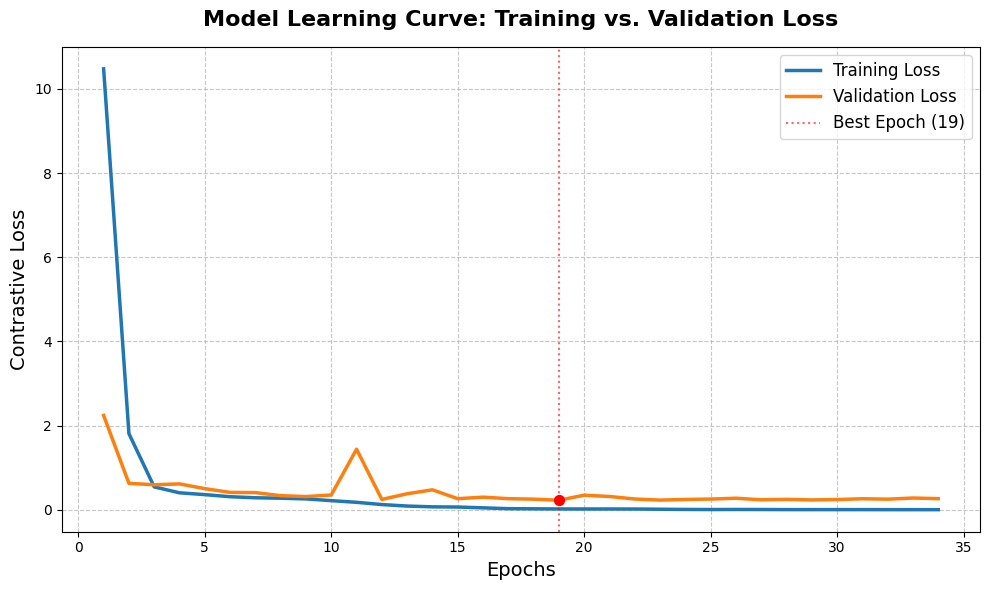

In [ ]:
# Cell 5.5 - Training & Validation Loss Visualization
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, val_losses):
    """
    Plots the training and validation loss curves generated during the training loop.
    """
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', linewidth=2.5) # Blue
    plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2.5) # Orange

    # Formatting the plot
    plt.title('Model Learning Curve: Training vs. Validation Loss', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Contrastive Loss', fontsize=14)

    # Adding a grid for easier readability
    plt.grid(True, linestyle='--', alpha=0.7)

    # Emphasize the lowest validation loss point
    best_epoch = np.argmin(val_losses) + 1
    best_loss = np.min(val_losses)
    plt.axvline(x=best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best Epoch ({best_epoch})')
    plt.scatter(best_epoch, best_loss, color='red', s=50, zorder=5)

    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

# Ensure the training actually ran and the variables exist
try:
    if len(train_loss_history) > 0 and len(val_loss_history) > 0:
        plot_loss_curves(train_loss_history, val_loss_history)
    else:
        print("[!] Loss histories are empty. Make sure training completed successfully.")
except NameError:
    print("[!] 'train_loss_history' or 'val_loss_history' not found. Run Cell 5 first.")

### Final Test Set Evaluation & Metrics Dashboard

This cell loads the best saved model weights and evaluates them against the completely unseen test dataset. It calculates the optimal decision threshold using the ROC curve and generates a comprehensive admin dashboard, featuring a Confusion Matrix and the Area Under the Curve (AUC) plot to assess the system's final reliability.

Loading the best model for Final Testing...
Running predictions on the Test Set...
--------------------------------------------------
🏆 FINAL TEST SET RESULTS 🏆
--------------------------------------------------
Optimal Decision Threshold: 0.4042
Final Accuracy: 81.22%
Final F1-Score: 0.8157
Area Under Curve (AUC): 0.8983
--------------------------------------------------


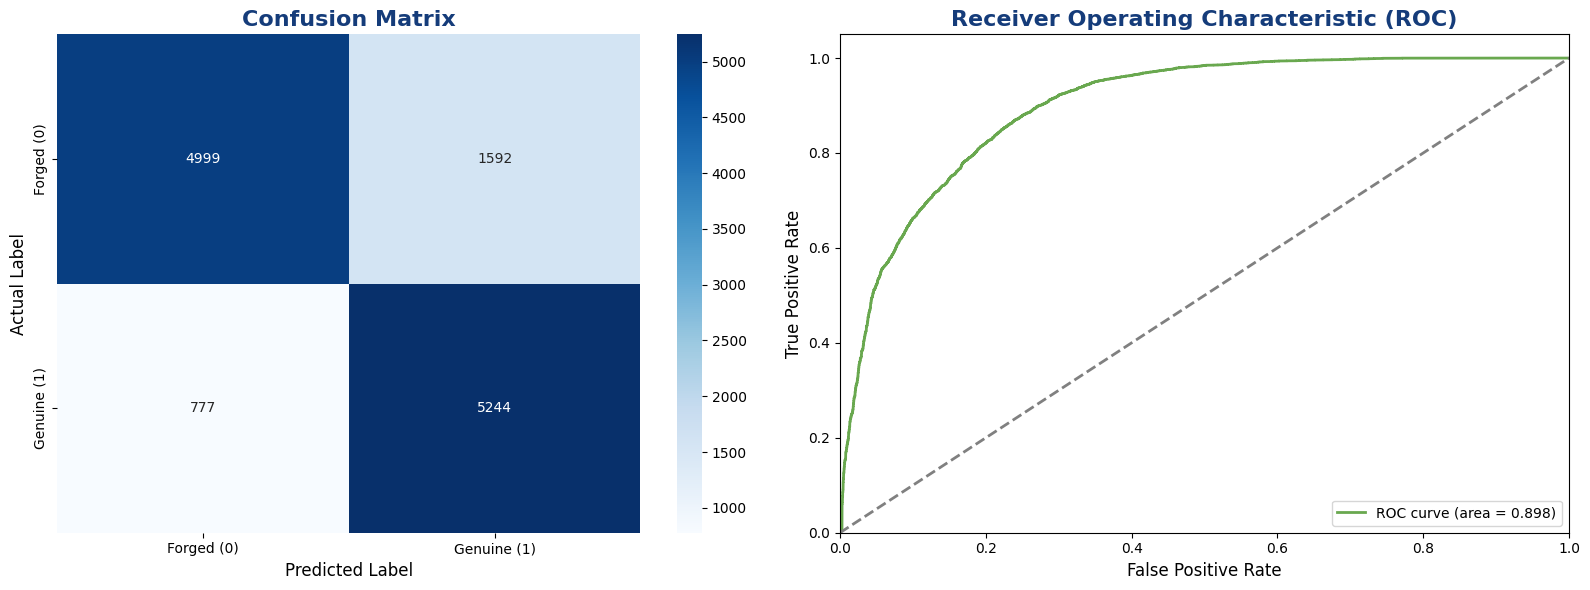

In [ ]:
# Cell 6 - Final Model Evaluation (Test Set), Confusion Matrix & ROC Curve
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, f1_score
import torch.nn.functional as F

print("Loading the best model for Final Testing...")

# 1. Initialize the model and load the winning weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model = SiameseResNet18(embedding_dim=128).to(device)
final_model.load_state_dict(torch.load('secure_sign_epoch_19_loss_0.2260_acc_81.79.pth', map_location=device))
final_model.eval()

test_loss = 0.0
all_test_preds_dist = []
all_test_labels = []

# 2. Run the model on the completely unseen Test Set
print("Running predictions on the Test Set...")
with torch.no_grad():
    for img1, img2, labels in test_dataloader:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        labels = labels.unsqueeze(1)

        output1, output2 = final_model(img1, img2)

        # Calculate distances
        distances = F.pairwise_distance(output1, output2, keepdim=True)
        all_test_preds_dist.extend(distances.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

all_test_preds_dist = np.array(all_test_preds_dist)
all_test_labels = np.array(all_test_labels)

# 3. Determine the optimal threshold for the Test Set using ROC
fpr, tpr, thresholds = roc_curve(all_test_labels, -all_test_preds_dist) # Negative distance because smaller distance = 1 (Genuine)
roc_auc = auc(fpr, tpr)

# Find the optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds[optimal_idx]

# 4. Calculate Final Metrics using the optimal threshold
binary_test_preds = (all_test_preds_dist <= optimal_threshold).astype(int)
test_acc = accuracy_score(all_test_labels, binary_test_preds)
test_f1 = f1_score(all_test_labels, binary_test_preds)

print("-" * 50)
print("🏆 FINAL TEST SET RESULTS 🏆")
print("-" * 50)
print(f"Optimal Decision Threshold: {optimal_threshold:.4f}")
print(f"Final Accuracy: {test_acc * 100:.2f}%")
print(f"Final F1-Score: {test_f1:.4f}")
print(f"Area Under Curve (AUC): {roc_auc:.4f}")
print("-" * 50)

# ==========================================
# 5. Visualizations for the Admin Dashboard
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix
cm = confusion_matrix(all_test_labels, binary_test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Forged (0)', 'Genuine (1)'],
            yticklabels=['Forged (0)', 'Genuine (1)'])
ax1.set_title('Confusion Matrix', fontsize=16, fontweight='bold', color='#153c7a')
ax1.set_ylabel('Actual Label', fontsize=12)
ax1.set_xlabel('Predicted Label', fontsize=12)

# Plot 2: ROC Curve
ax2.plot(fpr, tpr, color='#69a84f', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold', color='#153c7a')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

#**CNN**

In [ ]:
# Cell 6 - Final Evaluation on Test Set
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import glob
import os

print("Loading the best model for Final Testing...")

# Find the best saved model from the current run
saved_models = glob.glob('secure_sign_epoch_*.pth')
if saved_models:
    # Sort by validation loss (assuming filename format contains loss)
    best_model_path = sorted(saved_models, key=lambda x: float(x.split('_loss_')[1].split('_')[0]))[0]
    model.load_state_dict(torch.load(best_model_path))
    print(f"Loaded: {best_model_path}")
else:
    print("No saved model found, using current model weights.")

model.eval()
test_preds_dist = []
test_labels = []

print("Running predictions on the Test Set...")

with torch.no_grad():
    # AMP can be used here as well for faster inference
    for img1, img2, labels in test_dataloader:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

        with torch.autocast('cuda'):
            output1, output2 = model(img1, img2)

        distances = F.pairwise_distance(output1, output2, keepdim=True)
        test_preds_dist.extend(distances.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_preds_dist = np.array(test_preds_dist)
test_labels = np.array(test_labels)

# Use the compute_accuracy_roc function to find the optimal threshold for the test set
test_acc_roc, optimal_thresh = compute_accuracy_roc(test_preds_dist, test_labels)

# Generate binary predictions based on the optimal threshold
# Distance <= threshold means Genuine (1), else Forged (0)
binary_preds = (test_preds_dist <= optimal_thresh).astype(int)

# Calculate final metrics
final_acc = accuracy_score(test_labels, binary_preds)
final_f1 = f1_score(test_labels, binary_preds, zero_division=0)

# Calculate AUC (Note: ROC AUC usually expects probabilities, so we invert distances)
# Lower distance = higher probability of being genuine
inverted_distances = -test_preds_dist
auc_score = roc_auc_score(test_labels, inverted_distances)

print("\n" + "-" * 50)
print("🏆 FINAL TEST SET RESULTS 🏆")
print("-" * 50)
print(f"Optimal Decision Threshold: {optimal_thresh:.4f}")
print(f"Final Accuracy: {final_acc*100:.2f}%")
print(f"Final F1-Score: {final_f1:.4f}")
print(f"Area Under Curve (AUC): {auc_score:.4f}")
print("-" * 50)

Loading the best model for Final Testing...
Loaded: secure_sign_epoch_50_loss_0.2009_acc_83.48.pth
Running predictions on the Test Set...

--------------------------------------------------
🏆 FINAL TEST SET RESULTS 🏆
--------------------------------------------------
Optimal Decision Threshold: 0.3999
Final Accuracy: 84.32%
Final F1-Score: 0.8404
Area Under Curve (AUC): 0.9231
--------------------------------------------------


#**CNN**

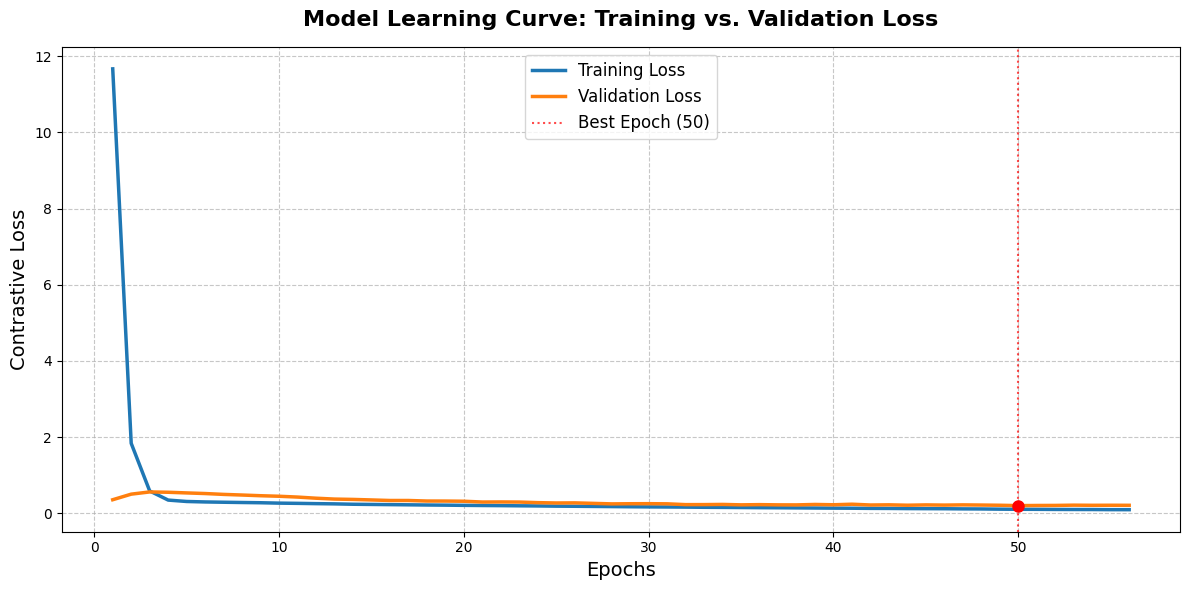

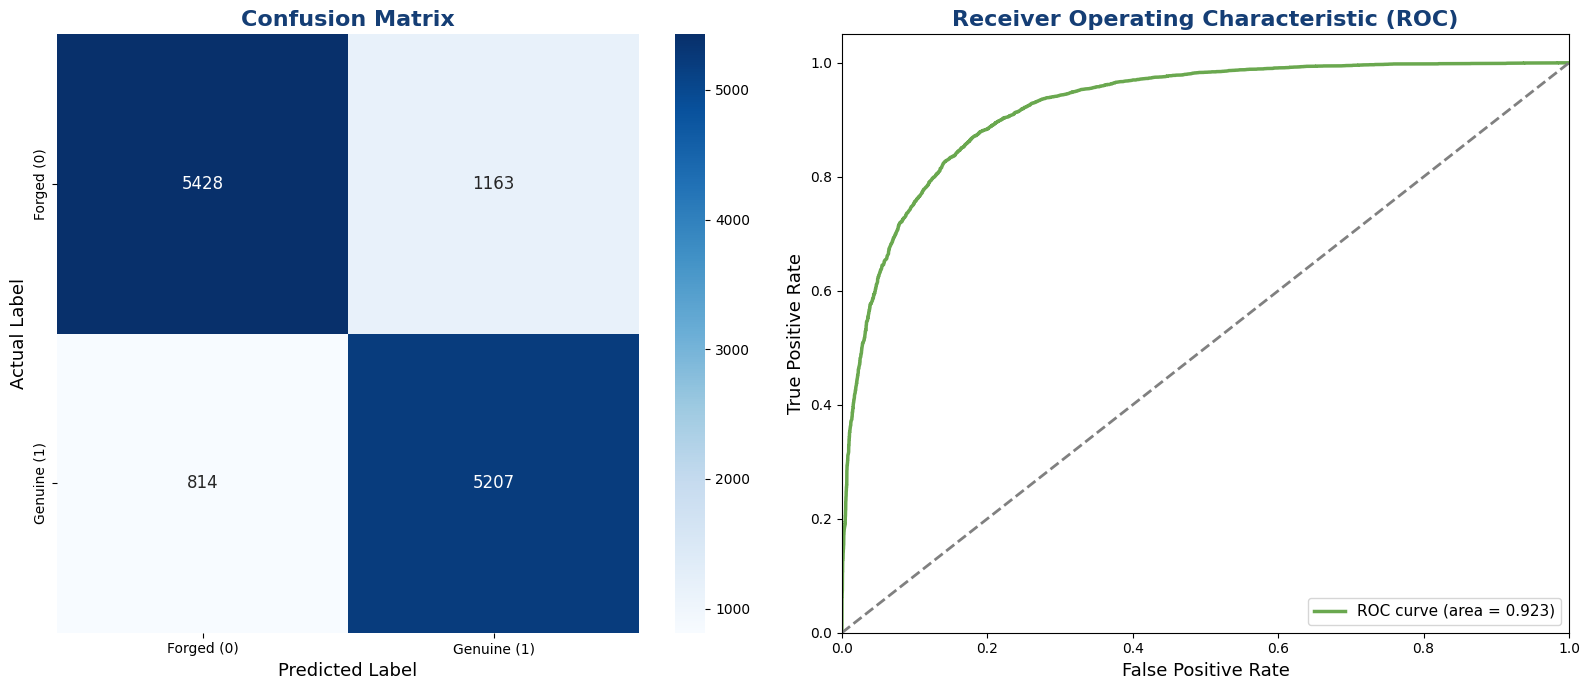

In [ ]:
# Cell 7 - Generate Evaluation Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure styling is clean and professional
plt.style.use('default')

# 1. Plot Model Learning Curve (Training vs. Validation Loss)
plt.figure(figsize=(12, 6))
epochs = range(1, len(train_loss_history) + 1)

# Using specific blue and orange for clarity
plt.plot(epochs, train_loss_history, label='Training Loss', color='#1f77b4', linewidth=2.5)
plt.plot(epochs, val_loss_history, label='Validation Loss', color='#ff7f0e', linewidth=2.5)

# Mark the best epoch
if saved_models:
    best_epoch_str = best_model_path.split('_epoch_')[1].split('_')[0]
    best_epoch = int(best_epoch_str)
    best_val = val_loss_history[best_epoch - 1]

    plt.axvline(x=best_epoch, color='red', linestyle=':', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    plt.plot(best_epoch, best_val, marker='o', markersize=8, color="red")

plt.title('Model Learning Curve: Training vs. Validation Loss', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Contrastive Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrix & ROC Curve Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Confusion Matrix ---
cm = confusion_matrix(test_labels, binary_preds)
# Using a blue-themed heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Forged (0)', 'Genuine (1)'],
            yticklabels=['Forged (0)', 'Genuine (1)'],
            annot_kws={"size": 12})

axes[0].set_title('Confusion Matrix', fontsize=16, fontweight='bold', color='#153e75')
axes[0].set_xlabel('Predicted Label', fontsize=13)
axes[0].set_ylabel('Actual Label', fontsize=13)

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(test_labels, inverted_distances)

axes[1].plot(fpr, tpr, color='#6aa84f', linewidth=2.5, label=f'ROC curve (area = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=13)
axes[1].set_ylabel('True Positive Rate', fontsize=13)
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold', color='#153e75')
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# @title
# Cell 7 - Download the Best Model
try:
    files.download('secure_sign_best_model.pth')
    print("Download initiated for 'secure_sign_best_model.pth'. Check your browser downloads.")
except Exception as e:
    print("Not running in Colab or download failed. File is saved in the local directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated for 'secure_sign_best_model.pth'. Check your browser downloads.


In [ ]:
# @title
# Cell 8 - Visualize Data Pipeline Stages for the Project Book
import os
import random
import cv2
import torch
import numpy as np
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image

def visualize_pipeline_stages(base_dir):
    if base_dir is None or not os.path.exists(base_dir):
        print("[!] Source directory not found. Please ensure data is extracted.")
        return

    # Find all original images
    org_dir = os.path.join(base_dir, 'full_org')
    if not os.path.exists(org_dir):
        print(f"[!] Could not find 'full_org' in {base_dir}")
        return

    all_files = [f for f in os.listdir(org_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not all_files:
        print("[!] No images found in the directory.")
        return

    # Select a random signature
    random_file = random.choice(all_files)
    img_path = os.path.join(org_dir, random_file)

    # Stage 1: Load Original
    img_original = Image.open(img_path).convert('L') # Load as Grayscale

    # Stage 2: Apply Offline Augmentation Simulation
    aug_transform = T.Compose([
        T.RandomRotation(degrees=10, fill=255),
        T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), fill=255)
    ])
    img_augmented = aug_transform(img_original)

    # Stage 3: Model Input Preprocessing (Resize to 224x224)
    # Convert PIL back to numpy array as OpenCV does in our pipeline
    img_aug_np = np.array(img_augmented)
    img_final = cv2.resize(img_aug_np, (224, 224))

    # Plotting the stages
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Data Pipeline Processing Stages\nFile: {random_file}', fontsize=16)

    # Plot 1: Original
    axes[0].imshow(img_original, cmap='gray')
    axes[0].set_title('1. Original Signature\n(Raw Data)')
    axes[0].axis('off')

    # Plot 2: Augmented
    axes[1].imshow(img_augmented, cmap='gray')
    axes[1].set_title('2. After Offline Augmentation\n(Rotation & Shift)')
    axes[1].axis('off')

    # Plot 3: Final Input
    axes[2].imshow(img_final, cmap='gray')
    axes[2].set_title('3. Final Model Input\n(Resized 224x224, Grayscale)')
    axes[2].axis('on') # Showing axes to emphasize the 224x224 dimensions

    plt.tight_layout()
    plt.show()

# Run the visualization directly on the current directory
print("Generating pipeline visualization...")
visualize_pipeline_stages('.')

### Evaluation Metrics Helper Function

This cell defines a reusable utility function that computes standard classification metrics. Based on a given distance threshold, it converts the continuous distance predictions into binary classifications (Genuine or Forged) and calculates Accuracy, Precision, Recall, and the F1-score.

In [ ]:
# Cell 9 - Evaluation Metrics Computation
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(distances, labels, threshold=1.0):
    """
    Computes Accuracy, Precision, Recall, and F1-score for a Siamese Network.

    distances: Tensor or numpy array of euclidean distances predicted by the model
    labels: Tensor or numpy array of true labels (1 for Genuine, 0 for Forged)
    threshold: The distance value below which a pair is considered Genuine
    """
    # Convert tensors to numpy arrays if needed
    if torch.is_tensor(distances):
        distances = distances.cpu().detach().numpy()
    if torch.is_tensor(labels):
        labels = labels.cpu().detach().numpy()

    # Classify based on the threshold
    # If distance < threshold -> Predict 1 (Genuine)
    # If distance >= threshold -> Predict 0 (Forged)
    predictions = (distances < threshold).astype(int)

    # Compute metrics
    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    return acc, precision, recall, f1

print("Metrics function defined successfully.")

Metrics function defined successfully.


### Visual Prediction Examples (Test Set)

This cell randomly selects a batch from the test set and visually demonstrates the model's inference capabilities. It displays the anchor image alongside the test image, showing the calculated mathematical distance and the optimal threshold, and uses color-coded text to indicate whether the model's prediction was correct.


2. VISUAL PREDICTION EXAMPLES (Randomly Selected)


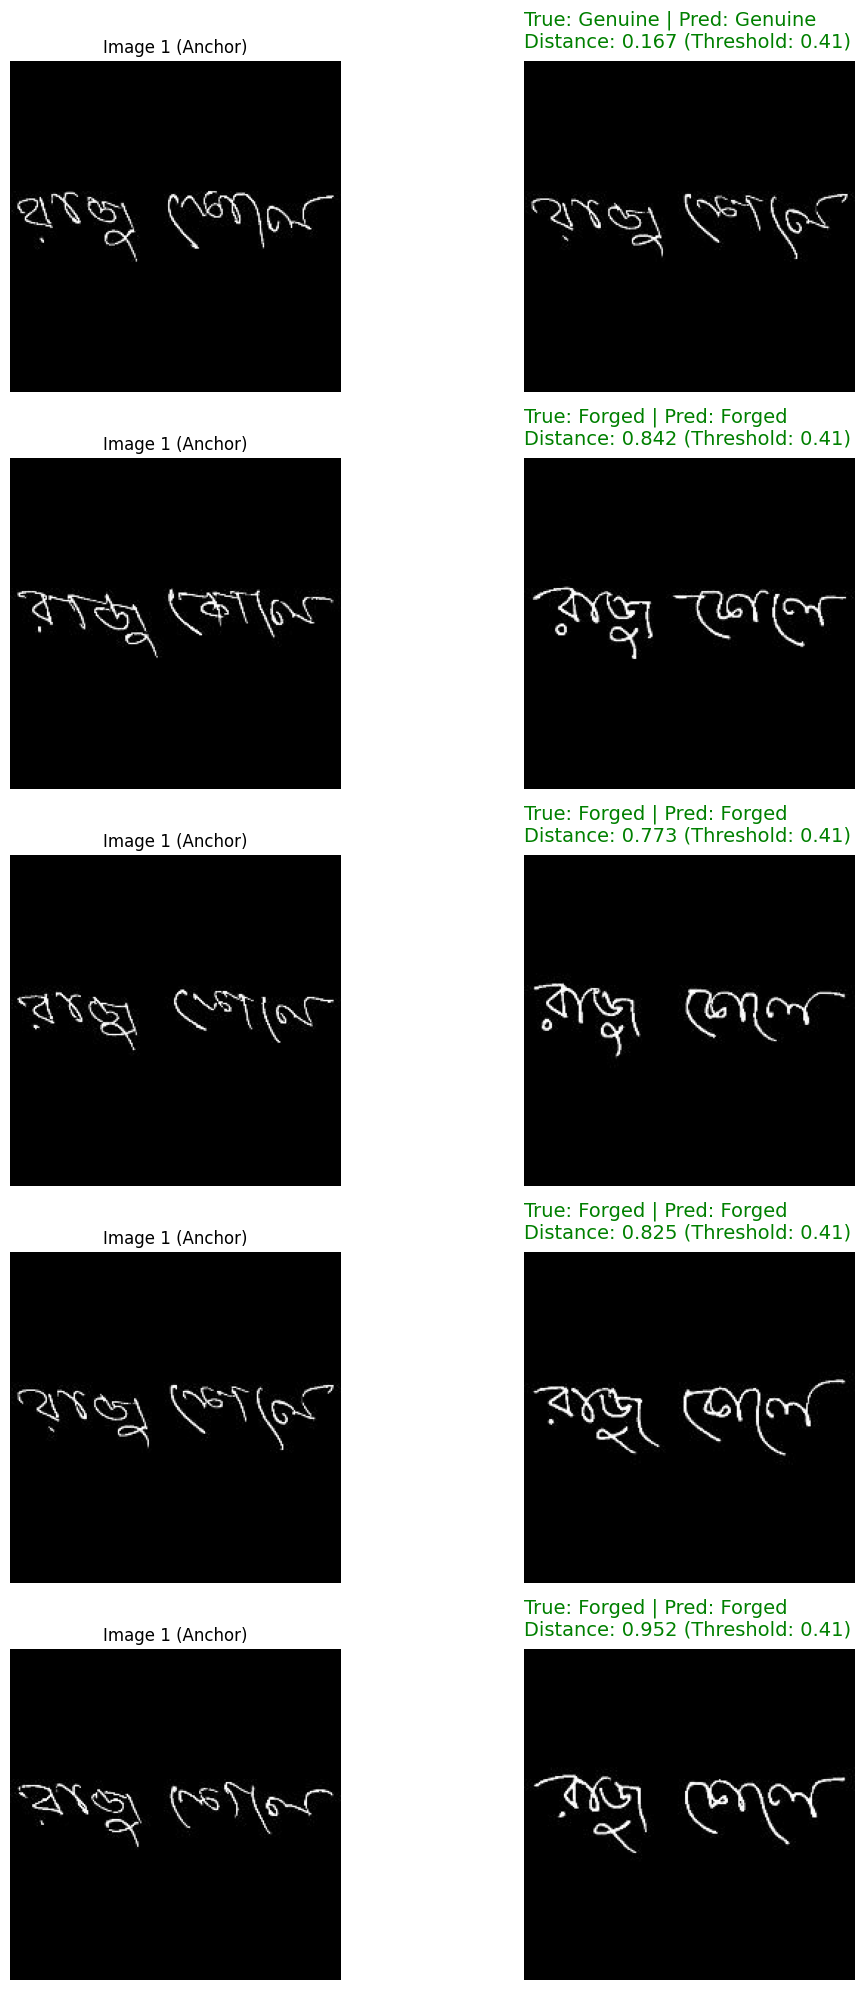

In [ ]:
# Cell 10 - Confusion Matrix & Random Visual Predictions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve
import torch
import torch.nn.functional as F
import numpy as np
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = 'secure_sign_epoch_50_loss_0.2009_acc_83.48.pth'

# --- NEW: Added the missing helper function ---
def compute_accuracy_roc(distances, labels):
    fpr, tpr, thresholds = roc_curve(labels, -distances)
    optimal_idx = np.argmax(tpr - fpr)
    best_thresh = -thresholds[optimal_idx]
    preds = (distances <= best_thresh).astype(int)
    acc = np.mean(preds == labels)
    return acc, best_thresh
# ----------------------------------------------

# 1. Load the Best Model
model = CustomSiameseCNN(embedding_dim=128).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# 2. Run Inference on Test Set to generate Confusion Matrix Data
all_true_labels = []
all_distances = []

with torch.no_grad():
    for img1, img2, labels in test_dataloader:
        img1, img2 = img1.to(device), img2.to(device)
        out1, out2 = model(img1, img2)
        distances = F.pairwise_distance(out1, out2)
        all_true_labels.extend(labels.cpu().numpy())
        all_distances.extend(distances.cpu().numpy())

all_true_labels = np.array(all_true_labels)
all_distances = np.array(all_distances)

# Calculate threshold dynamically
test_acc, best_thresh = compute_accuracy_roc(all_distances, all_true_labels)
predictions = (all_distances <= best_thresh).astype(int)


# ==========================================
# 4. SHOW RANDOM PREDICTION EXAMPLES
# ==========================================
print("\n" + "="*50)
print("2. VISUAL PREDICTION EXAMPLES (Randomly Selected)")
print("="*50)

num_examples = 5

# Pick a random batch from the dataloader
random_batch_idx = random.randint(0, len(test_dataloader) - 1)
for i, batch in enumerate(test_dataloader):
    if i == random_batch_idx:
        img1_batch, img2_batch, labels_batch = batch
        break

# Pick random indices from that specific batch
batch_size = len(labels_batch)
random_indices = random.sample(range(batch_size), min(num_examples, batch_size))

plt.figure(figsize=(12, 4 * num_examples))

for idx, i in enumerate(random_indices):
    im1 = img1_batch[i].to(device).unsqueeze(0)
    im2 = img2_batch[i].to(device).unsqueeze(0)
    true_label = int(labels_batch[i].item())

    with torch.no_grad():
        o1, o2 = model(im1, im2)
        dist = F.pairwise_distance(o1, o2).item()

    pred_label = 1 if dist <= best_thresh else 0

    # Display Image 1
    ax1 = plt.subplot(num_examples, 2, 2*idx + 1)
    ax1.imshow(im1.cpu().squeeze().numpy(), cmap='gray')
    ax1.set_title("Image 1 (Anchor)")
    ax1.axis('off')

    # Display Image 2
    ax2 = plt.subplot(num_examples, 2, 2*idx + 2)
    ax2.imshow(im2.cpu().squeeze().numpy(), cmap='gray')
    ax2.axis('off')

    # Formatting text colors
    color = 'green' if pred_label == true_label else 'red'
    true_text = 'Genuine' if true_label == 1 else 'Forged'
    pred_text = 'Genuine' if pred_label == 1 else 'Forged'

    title_text = (f"True: {true_text} | Pred: {pred_text}\n"
                  f"Distance: {dist:.3f} (Threshold: {best_thresh:.2f})")
    ax2.set_title(title_text, color=color, fontsize=14, loc='left', pad=10)

plt.tight_layout()
plt.show()

### End-to-End Bank Verification System (Production)

This cell simulates a real-world production environment for signature verification. It employs a robust contour-based algorithm to extract multiple reference signatures from a single document. Each anchor is then rigorously preprocessed using the unified pipeline and compared against an incoming customer signature, calculating an average network distance to output a final "Approved" or "Rejected" bank decision.

✅ Successfully extracted 4 reference signatures (sorted top to bottom).
   -> Distance to Anchor 1: 1.3138
   -> Distance to Anchor 2: 1.5986
   -> Distance to Anchor 3: 1.2785
   -> Distance to Anchor 4: 1.1729
----------------------------------------
Average Network Distance: 1.3409 (Threshold: 0.28)
🚨 Bank Decision: REJECTED (Suspected Forgery)
----------------------------------------


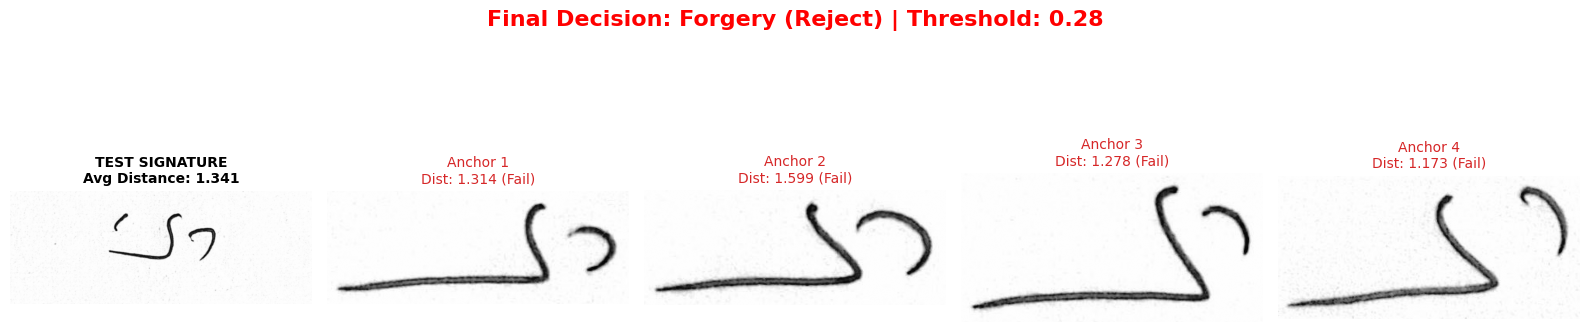

In [ ]:
# Cell 11 - Bank Verification System (Robust Extraction & Unified Processing)
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# 1. Define the production transform (Must match training preprocessing)
bank_production_transforms = transforms.Compose([
    UnifiedSignatureTransform(), # Includes inverse binarization, deskew, crop, pad
    transforms.ToTensor()
])

def extract_vertical_anchors(image_path, min_area=800):
    """
    Extracts signatures that are written one under the other.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"[!] Error: Could not load image at {image_path}")
        return []

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel_clean = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    clean_thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean, iterations=1)

    kernel_merge = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 15))
    connected = cv2.morphologyEx(clean_thresh, cv2.MORPH_CLOSE, kernel_merge, iterations=1)

    contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bounding_boxes = []
    img_h, img_w = gray.shape

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = w * h
        if area > min_area and area < (img_w * img_h * 0.8) and h > 20:
            bounding_boxes.append((x, y, w, h))

    bounding_boxes = sorted(bounding_boxes, key=lambda b: b[1])

    extracted_anchors = []
    for idx, (x, y, w, h) in enumerate(bounding_boxes):
        pad = 15
        y1 = max(0, y - pad)
        y2 = min(gray.shape[0], y + h + pad)
        x1 = max(0, x - pad)
        x2 = min(gray.shape[1], x + w + pad)

        roi = gray[y1:y2, x1:x2]
        pil_img = Image.fromarray(roi).convert('L')
        extracted_anchors.append(pil_img)

    return extracted_anchors

def verify_customer_signature(model, anchor_img_path, test_img_path, threshold=0.28):
    """
    Bank Decision System: Uses unified preprocessing before passing to model.
    """
    model.eval()

    # Extract anchors
    anchors = extract_vertical_anchors(anchor_img_path)

    if len(anchors) < 3 or len(anchors) > 10:
        print(f"❌ Bank Policy Error: Found {len(anchors)} signatures. System requires between 3 and 10.")
        return

    print(f"✅ Successfully extracted {len(anchors)} reference signatures (sorted top to bottom).")

    test_img = Image.open(test_img_path).convert('L')
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Process test signature through unified transform (Black bg, white ink)
    test_tensor = bank_production_transforms(test_img).unsqueeze(0).to(device)

    distances = []
    processed_anchors_for_display = []

    with torch.no_grad():
        for i, anchor in enumerate(anchors):
            # Process anchor through unified transform
            anchor_tensor = bank_production_transforms(anchor).unsqueeze(0).to(device)

            # Save for visualization (convert back to numpy to show the black bg/white ink)
            processed_anchors_for_display.append(anchor_tensor.cpu().squeeze().numpy())

            output1, output2 = model(anchor_tensor, test_tensor)
            euclidean_distance = torch.nn.functional.pairwise_distance(output1, output2).item()
            distances.append(euclidean_distance)
            print(f"   -> Distance to Anchor {i+1}: {euclidean_distance:.4f}")

    avg_distance = sum(distances) / len(distances)
    is_genuine = avg_distance < threshold

    print("-" * 40)
    print(f"Average Network Distance: {avg_distance:.4f} (Threshold: {threshold})")
    if is_genuine:
        print("🏦 Bank Decision: APPROVED (Genuine Signature)")
    else:
        print("🚨 Bank Decision: REJECTED (Suspected Forgery)")
    print("-" * 40)

    # Visual Display
    fig, axes = plt.subplots(1, len(anchors) + 1, figsize=(16, 4))
    main_color = 'green' if is_genuine else 'red'
    decision_text = "Genuine (Match)" if is_genuine else "Forgery (Reject)"
    fig.suptitle(f"Final Decision: {decision_text} | Threshold: {threshold}",
                 color=main_color, fontsize=16, fontweight='bold', y=1.05)

    # Plot TEST Signature (Processed)
    axes[0].imshow(test_tensor.cpu().squeeze().numpy(), cmap='gray')
    axes[0].set_title(f"TEST SIGNATURE\nAvg Distance: {avg_distance:.3f}", fontweight='bold', fontsize=10)
    axes[0].axis('off')

    # Plot Anchors (Processed)
    for i, proc_anchor in enumerate(processed_anchors_for_display):
        ax = axes[i + 1]
        ax.imshow(proc_anchor, cmap='gray')

        dist = distances[i]
        anchor_pass = dist < threshold
        color = 'green' if anchor_pass else '#d62728'
        status_text = "Pass" if anchor_pass else "Fail"

        ax.set_title(f"Anchor {i+1}\nDist: {dist:.3f} ({status_text})", color=color, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# Execution Block
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseResNet18(embedding_dim=128).to(device)

try:
    model.load_state_dict(torch.load('secure_sign_epoch_50_loss_0.2009_acc_83.48.pth', map_location=device, weights_only=True))
except Exception as e:
    print("[!] Could not load model weights. Ensure 'secure_sign_epoch_50_loss_0.2009_acc_83.48.pth' exists.")

model.eval()

# Example call (Replace with actual filenames when running)
verify_customer_signature(model, 'img.jpg', 'test_img1.jpg', threshold=0.28)

#**Conclusion and Final Model Selection**

The primary objective of this comparative analysis was to identify the optimal deep learning architecture for the offline digital signature verification system. Evaluating the raw performance metrics reveals that both the pre-trained ResNet18 and the custom lightweight CNN achieved a nearly identical peak accuracy of approximately 83.5%. However, a deeper examination of their respective learning curves highlights a critical difference in their behavior and generalization capabilities.

The ResNet18 model, despite its depth and powerful feature extraction capabilities, exhibited severe overfitting during the later stages of training. While its training loss approached zero, the validation loss plateaued and ceased to improve, indicating that the network's high capacity caused it to memorize the relatively simple binary signature images rather than learning generalizable patterns. In contrast, the Custom CNN maintained a healthy, stable learning curve throughout the 50 epochs. The training and validation losses decreased in tandem, demonstrating the model's ability to effectively extract essential features without succumbing to overfitting.

Based on these empirical findings, the Custom CNN architecture proves to be the superior choice for this problem domain. It successfully balances high verification accuracy with robust generalization and computational efficiency. Consequently, this lightweight CNN is selected as the final production model for the system, ensuring reliable, fast, and stable performance when analyzing unseen signatures.